<a href="https://colab.research.google.com/github/joanitha25/Karagwe-malaria-prevalence/blob/main/revised_pfpr_RF_XGB_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PfPR2–10 Modelling Pipeline — Karagwe District, 2020–2024

This notebook implements the requested workflow: preprocessing, duplicate/missing-value handling, distributions, correlation analysis, retention of NDWI/NDMI/LST/Rainfall/Elevation/DistWater, nested spatial and leave-one-year-out CV, 80:20 benchmark, scatter/residual plots, SHAP, and relative importance.

In [1]:
# ============================================================
# 0. INSTALL LIBRARIES
# ============================================================

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap tensorflow rasterio pyproj joblib
# ============================================================
# PfPR2-10 MODELLING PIPELINE
# Karagwe District, Tanzania, 2020-2024
#
# Workflow:
# 1. Load yearly raster stacks + PfPR observations
# 2. Extract environmental predictors at PfPR locations
# 3. Data preprocessing: numeric conversion, invalid values,
#    missing-value and duplicate checks
# 4. Histograms / distribution plots
# 5. Pearson correlation analysis
# 6. Retain the predefined six predictors:
#       NDWI, NDMI, LST, Rainfall, Elevation, DistWater
# 7. Build spatial blocks
# 8. Nested spatial block CV (outer + inner CV)
# 9. Nested leave-one-year-out CV
# 10. Conventional 80:20 random-split benchmark
# 11. Select the final algorithm using the predefined primary
#     spatial validation scheme (not the random 80:20 result)
# 12. Refit selected model for deployment
# 13. Cross-validated scatter plots and residual diagnostics
# 14. SHAP analysis
# 15. Relative importance:
#       a) tree-based impurity importance
#       b) SHAP mean(|SHAP|) relative contribution
#       c) outer-fold permutation importance
#
# IMPORTANT:
# - Replace STACK_BAND_ORDER below if the band order in your GeoTIFFs
#   is different and the TIFFs do not contain band descriptions.
# - The 10-km spatial block size is configurable. For the manuscript,
#   run sensitivity at 5, 10 and 20 km if computationally feasible.
# ============================================================

# =========================
# 0. INSTALLATION (COLAB)
# =========================
# Uncomment if needed:
# !pip install -q rasterio pyproj xgboost shap seaborn joblib

import os
import re
import glob
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from rasterio.warp import transform as rio_transform
from pyproj import Transformer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
    LeaveOneGroupOut,
    RandomizedSearchCV
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# ============================================================
# 1. PATHS AND GLOBAL SETTINGS
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

STACK_DIR = "/content/drive/MyDrive/PfPR_Predictors/"
PFPR_FILE = "/content/drive/MyDrive/PfPR/pfpr_data.csv"

YEARS = [2020, 2021, 2022, 2023, 2024]

# Output directory. Change if desired.
OUTPUT_DIR = "/content/drive/MyDrive/PfPR_Project"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

# Spatial CV settings
BLOCK_SIZE_KM = 10
N_OUTER_SPLITS = 5

# Random search settings
RF_N_ITER = 20
XGB_N_ITER = 25

RETAINED_FEATURES = [
    "NDWI",
    "NDMI",
    "LST",
    "Rainfall",
    "Elevation",
    "DistWater"
]

TARGET = "pfpr_pct"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 740.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 164.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 1.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
Mounted at /content/drive


BUILDING PFPR TRAINING DATASET

Sampling 2020:
  Stack: /content/drive/MyDrive/PfPR_Predictors/Karagwe_Predictor_Stack2020.tif
  Points: 633

Sampling 2021:
  Stack: /content/drive/MyDrive/PfPR_Predictors/Karagwe_Predictor_Stack2021.tif
  Points: 633

Sampling 2022:
  Stack: /content/drive/MyDrive/PfPR_Predictors/Karagwe_Predictor_Stack2022.tif
  Points: 633

Sampling 2023:
  Stack: /content/drive/MyDrive/PfPR_Predictors/Karagwe_Predictor_Stack2023.tif
  Points: 633

Sampling 2024:
  Stack: /content/drive/MyDrive/PfPR_Predictors/Karagwe_Predictor_Stack2024.tif
  Points: 633

Raw combined dataset shape: (3165, 14)

Column names:
['latitude', 'longitude', 'year', 'pfpr_pct', 'NDVI', 'NDWI', 'NDMI', 'NDBI', 'MNDWI', 'LST', 'Rainfall', 'Elevation', 'Slope', 'DistWater']

Duplicate column names:
[]
Years found: [2020, 2021, 2022, 2023, 2024]

DATA PREPROCESSING

Missing values BEFORE cleaning:
latitude     0
longitude    0
year         0
pfpr_pct     0
NDWI         0
NDMI         0
LST     

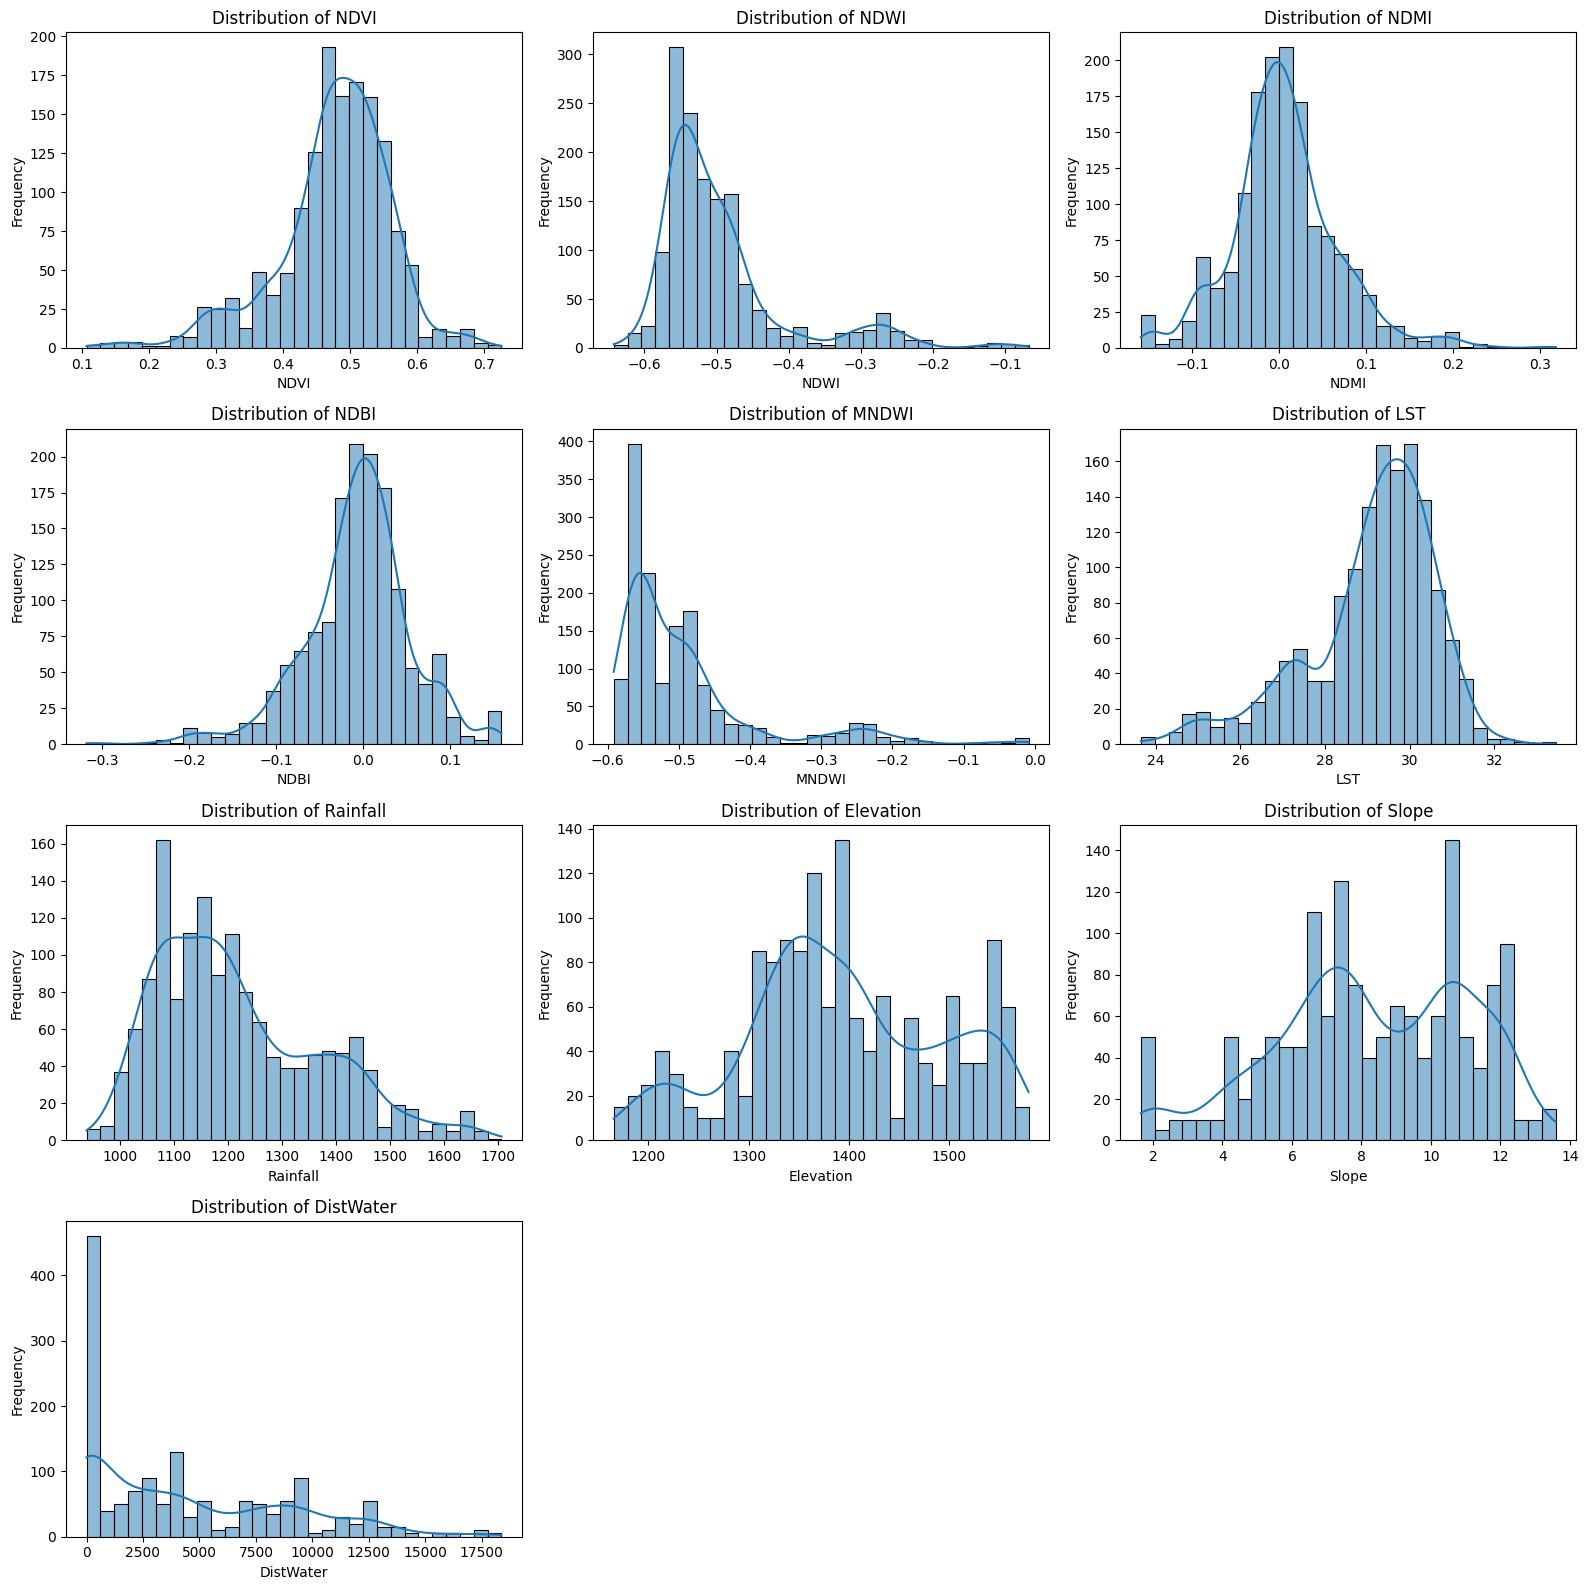

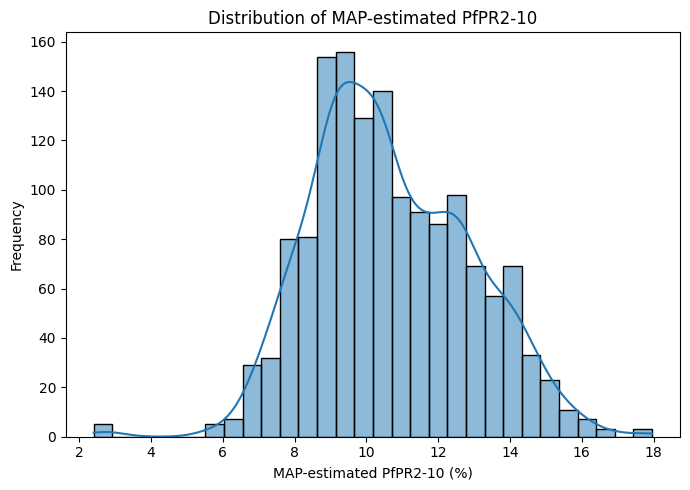


PEARSON CORRELATION ANALYSIS

Correlation matrix:
            NDVI   NDWI   NDMI   NDBI  MNDWI    LST  Rainfall  Elevation  \
NDVI       1.000 -0.895  0.399 -0.399 -0.628  0.015     0.225      0.133   
NDWI      -0.895  1.000 -0.013  0.013  0.895 -0.303    -0.155     -0.327   
NDMI       0.399 -0.013  1.000 -1.000  0.433 -0.697     0.221     -0.133   
NDBI      -0.399  0.013 -1.000  1.000 -0.433  0.697    -0.221      0.133   
MNDWI     -0.628  0.895  0.433 -0.433  1.000 -0.583    -0.039     -0.361   
LST        0.015 -0.303 -0.697  0.697 -0.583  1.000     0.126      0.195   
Rainfall   0.225 -0.155  0.221 -0.221 -0.039  0.126     1.000      0.013   
Elevation  0.133 -0.327 -0.133  0.133 -0.361  0.195     0.013      1.000   
Slope      0.145 -0.322 -0.207  0.207 -0.391  0.296     0.030      0.820   
DistWater  0.249 -0.433 -0.250  0.250 -0.504  0.406     0.213      0.385   
pfpr_pct  -0.363  0.366 -0.154  0.154  0.258  0.039    -0.336     -0.204   

           Slope  DistWater  pfpr_pc

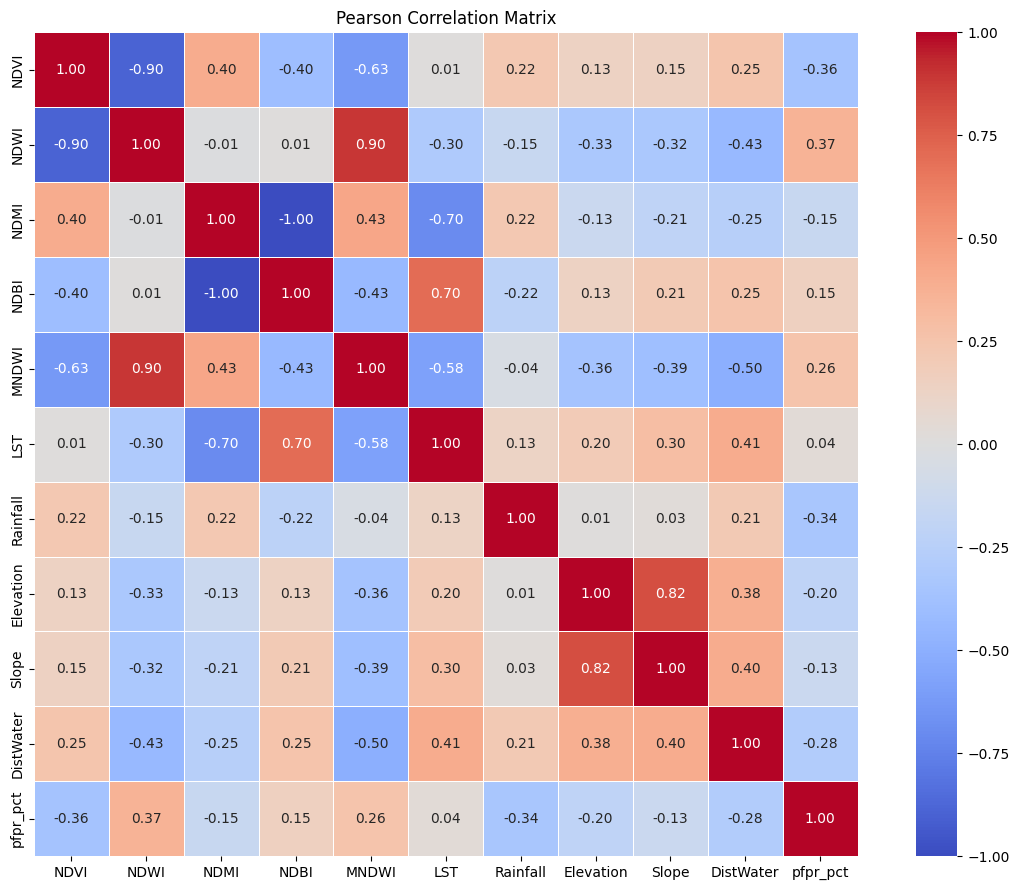


Highly correlated predictor pairs (|r| >= 0.70):
  Variable_1 Variable_2  Pearson_r  Absolute_r
2       NDMI       NDBI     -1.000       1.000
0       NDVI       NDWI     -0.895       0.895
1       NDWI      MNDWI      0.895       0.895
3  Elevation      Slope      0.820       0.820

RETAINED PREDICTORS
['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']

SPATIAL BLOCK CREATION
Metric CRS: EPSG:32736
Spatial block size: 10 km
Number of spatial blocks: 54

NESTED CROSS-VALIDATION
Random Forest | Spatial fold 1: R2=0.5821, RMSE=1.3597, MAE=0.8363
Random Forest | Spatial fold 2: R2=0.2393, RMSE=1.5758, MAE=0.9135
Random Forest | Spatial fold 3: R2=0.6772, RMSE=1.1660, MAE=0.8930
Random Forest | Spatial fold 4: R2=0.4834, RMSE=1.7054, MAE=1.2650
Random Forest | Spatial fold 5: R2=0.5818, RMSE=1.5722, MAE=1.2063
Random Forest | Year 2020: R2=-1.4671, RMSE=2.1081, MAE=1.8810
Random Forest | Year 2021: R2=0.3949, RMSE=1.5252, MAE=1.2269
Random Forest | Year 2022: R2=0.2624, RMSE=1.

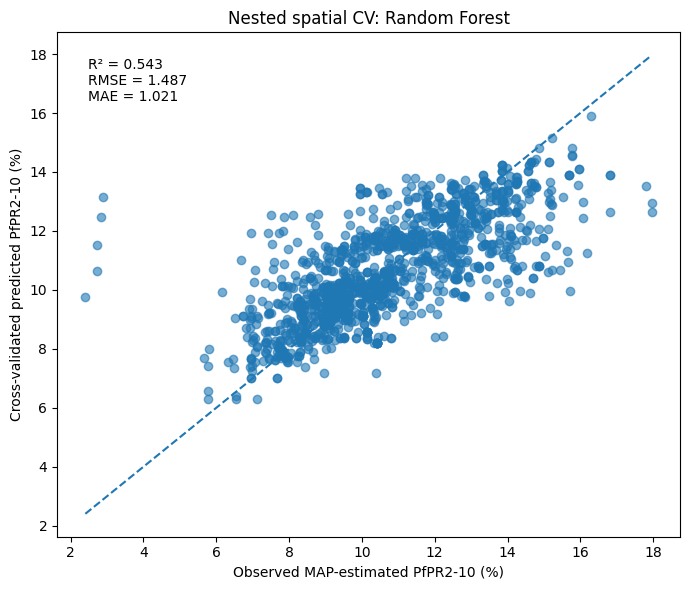

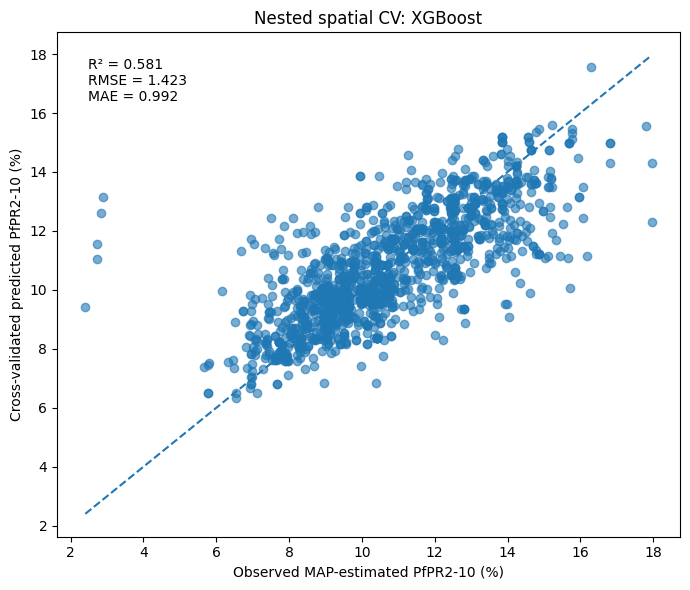

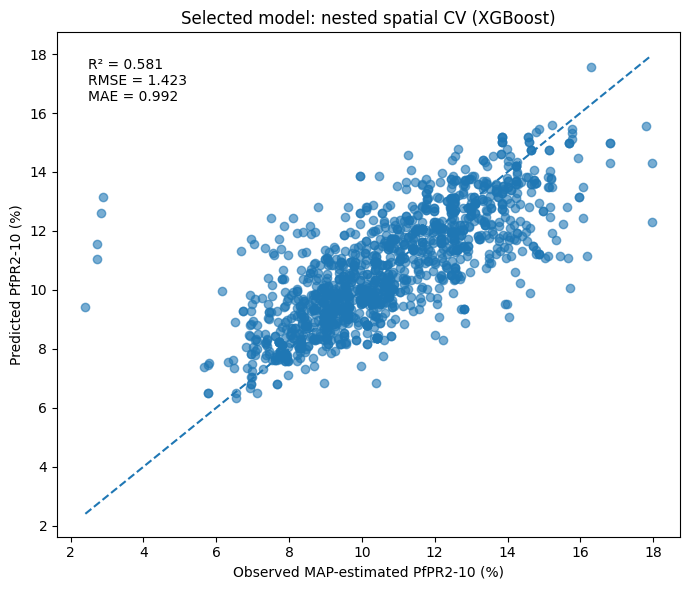

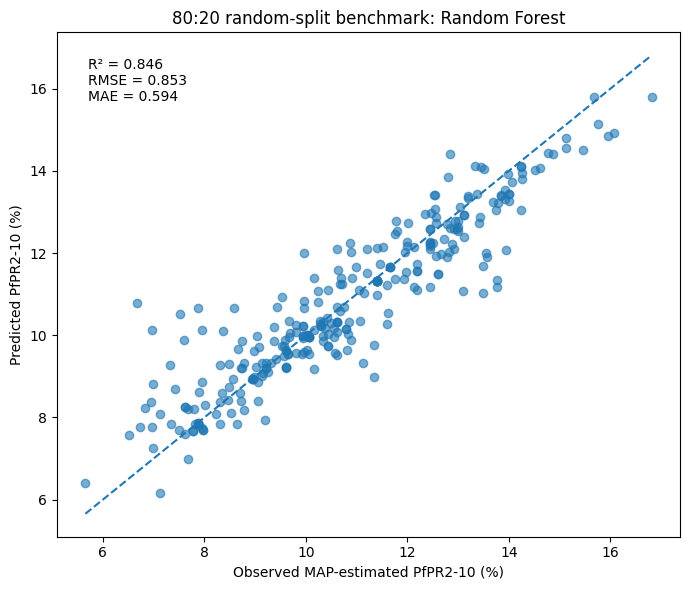

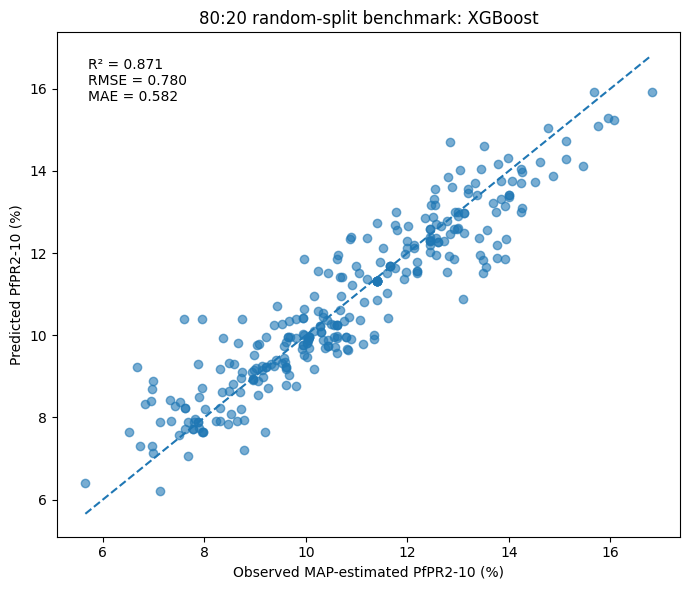

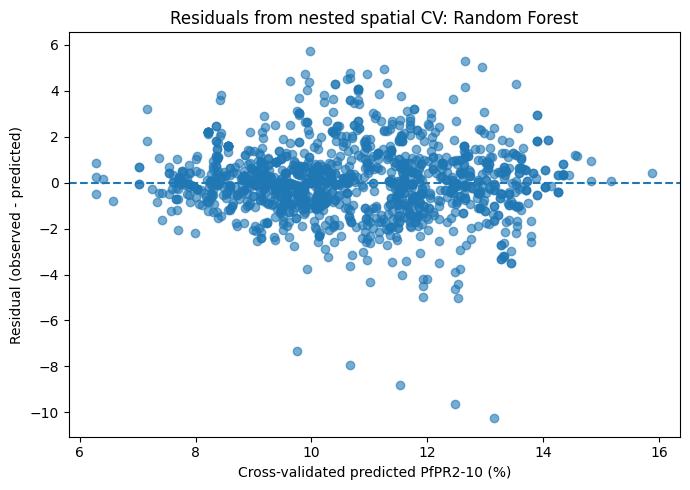

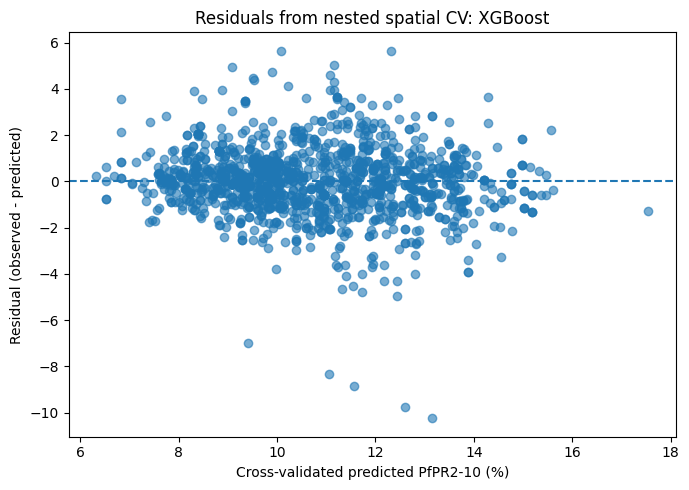


FINAL DEPLOYMENT MODEL
Selected algorithm: XGBoost
Final hyperparameters:
{'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

TREE-BASED RELATIVE FEATURE IMPORTANCE
     Feature  Impurity_Importance  Relative_Importance_Percent
0       NDWI             0.426125                    42.612457
1  Elevation             0.157423                    15.742323
2       NDMI             0.157358                    15.735769
3   Rainfall             0.099945                     9.994512
4        LST             0.087625                     8.762452
5  DistWater             0.071525                     7.152491


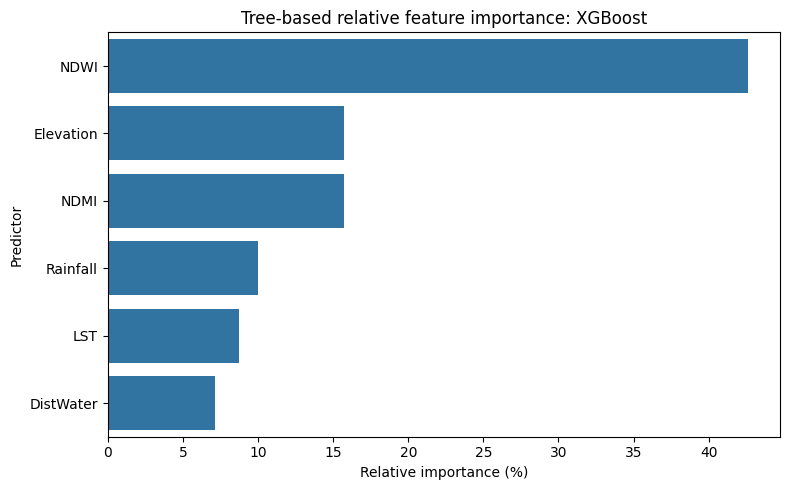


OUTER-FOLD PERMUTATION IMPORTANCE
     Feature  Mean_Permutation_R2  SD_Permutation_R2  \
0       NDWI             0.680740           0.276432   
1  Elevation             0.234999           0.124022   
2       NDMI             0.155314           0.112334   
3   Rainfall             0.151519           0.014629   
4        LST             0.119801           0.062698   
5  DistWater             0.036190           0.031066   

   Relative_Permutation_Importance_Percent  
0                                49.380427  
1                                17.046693  
2                                11.266349  
3                                10.991071  
4                                 8.690260  
5                                 2.625200  


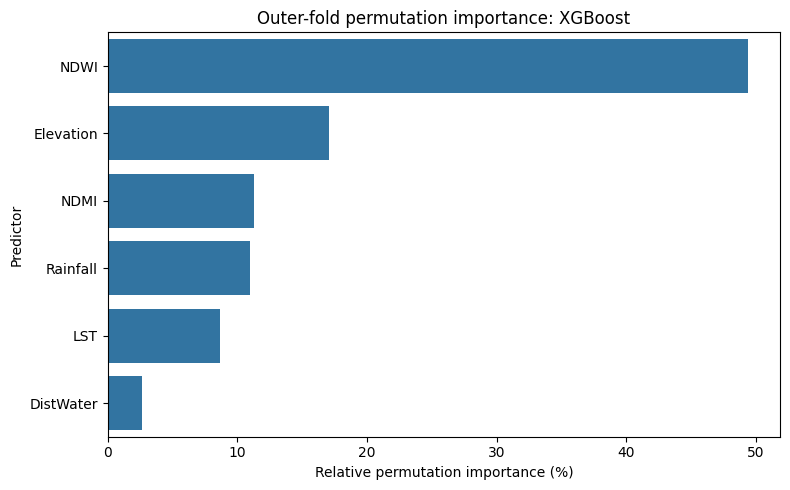


SHAP ANALYSIS

Global SHAP importance:
     Feature  Mean_Absolute_SHAP  Relative_SHAP_Importance_Percent
0       NDWI            1.153545                         40.416534
1  Elevation            0.461655                         16.174906
2   Rainfall            0.406606                         14.246188
3        LST            0.336041                         11.773808
4       NDMI            0.310335                         10.873141
5  DistWater            0.185959                          6.515425


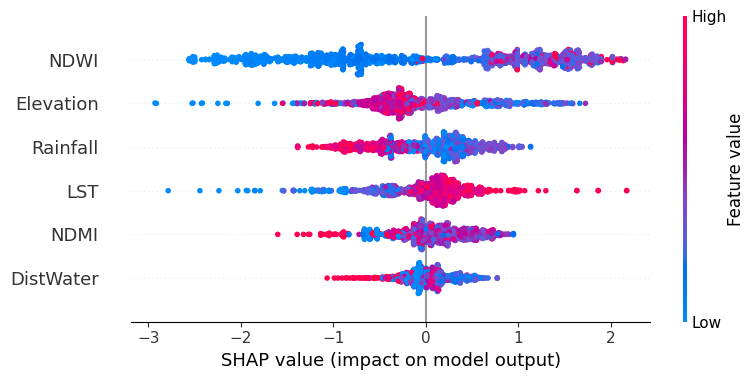

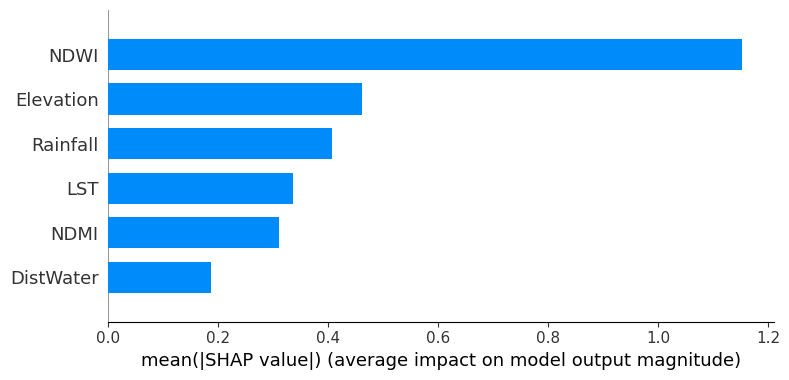

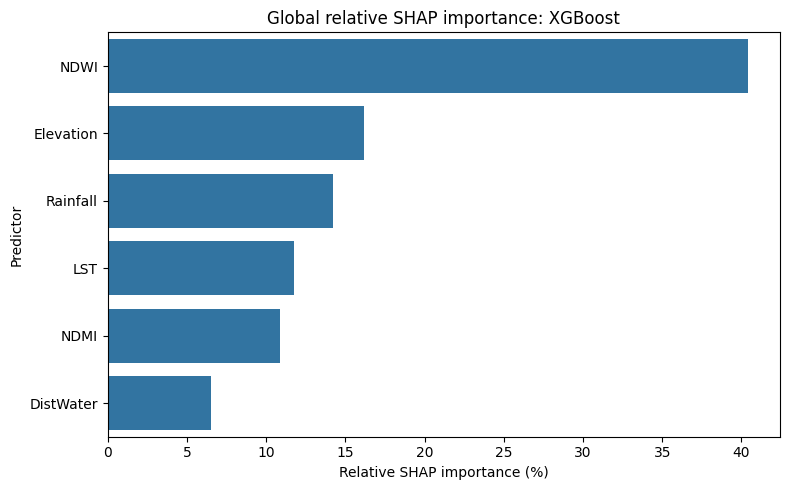


OPTIONAL MORAN'S I RESIDUAL DIAGNOSTIC
Moran's I requires libpysal and esda. Install with: !pip install -q libpysal esda

ANALYSIS COMPLETE
Output directory:
/content/drive/MyDrive/PfPR_Project

Retained predictors:
['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']

Primary validation scheme:
Nested spatial block CV

Selected model:
XGBoost

Primary nested spatial CV performance:
     Model        R2      RMSE       MAE
1  XGBoost  0.550532  1.409296  0.993636

80:20 benchmark:
           Model        R2      RMSE       MAE
0  Random Forest  0.845603  0.852957  0.593673
1        XGBoost  0.870734  0.780458  0.581722

The 80:20 benchmark is reported separately and was not used as the primary basis for model selection.


In [2]:

STACK_BAND_ORDER = [
    "NDVI",
    "NDWI",
    "NDMI",
    "NDBI",
    "MNDWI",
    "LST",
    "Rainfall",
    "Elevation",
    "Slope",
    "DistWater"
]

CANDIDATE_FEATURES = STACK_BAND_ORDER.copy()

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def normalise_name(name):
    """Convert column/band names to a consistent form."""
    name = str(name).strip()
    name = re.sub(r"[^A-Za-z0-9]+", "_", name)
    return name.strip("_")


def canonical_band_name(name):
    """
    Map common variations in raster band descriptions to the study names.
    """
    if name is None:
        return None

    raw = normalise_name(name)
    low = raw.lower()

    aliases = {
        "ndvi": "NDVI",
        "ndwi": "NDWI",
        "ndmi": "NDMI",
        "ndbi": "NDBI",
        "mndwi": "MNDWI",
        "lst": "LST",
        "landsurfacetemperature": "LST",
        "land_surface_temperature": "LST",
        "rainfall": "Rainfall",
        "rain": "Rainfall",
        "precipitation": "Rainfall",
        "elevation": "Elevation",
        "dem": "Elevation",
        "slope": "Slope",
        "distwater": "DistWater",
        "distancewater": "DistWater",
        "distance_to_water": "DistWater",
        "distance_to_permanent_water": "DistWater"
    }

    return aliases.get(low, raw)


def find_year_stack(year):
    """
    Find a yearly GeoTIFF stack. The function accepts common naming patterns.
    """
    tif_files = sorted(
        glob.glob(os.path.join(STACK_DIR, "*.tif")) +
        glob.glob(os.path.join(STACK_DIR, "*.tiff"))
    )

    # Prefer filenames containing the exact year.
    year_matches = [
        f for f in tif_files
        if re.search(rf"(?<!\d){year}(?!\d)", os.path.basename(f))
    ]

    if not year_matches:
        raise FileNotFoundError(
            f"No GeoTIFF stack containing year {year} was found in {STACK_DIR}"
        )

    # If several files match, use the first deterministic match.
    return sorted(year_matches)[0]


def get_stack_band_names(src):
    """
    Read band descriptions when available. Otherwise use STACK_BAND_ORDER.
    """
    descriptions = list(src.descriptions)

    if (
        len(descriptions) == src.count
        and all(d is not None and str(d).strip() for d in descriptions)
    ):
        names = [canonical_band_name(d) for d in descriptions]
        if len(set(names)) == len(names):
            return names

    if src.count != len(STACK_BAND_ORDER):
        raise ValueError(
            f"Stack has {src.count} bands, but no usable band descriptions were "
            f"found and STACK_BAND_ORDER contains {len(STACK_BAND_ORDER)} names."
        )

    return STACK_BAND_ORDER.copy()


def prepare_pfpr_dataframe(path):
    """
    Read and standardise the PfPR CSV.

    Expected information:
      latitude / longitude / year / pfpr or pfpr_pct

    If pfpr is supplied as a proportion in [0, 1], it is converted to percent.
    If it is already in percentage units, it is retained.
    """
    df = pd.read_csv(path)
    df.columns = [normalise_name(c) for c in df.columns]

    rename = {
        "Latitude": "latitude",
        "latitude": "latitude",
        "lat": "latitude",
        "Longitude": "longitude",
        "longitude": "longitude",
        "lon": "longitude",
        "Year": "year",
        "year": "year",
        "PfPR": "pfpr",
        "pfpr": "pfpr",
        "PfPR2_10": "pfpr",
        "pfpr2_10": "pfpr",
        "PfPR_pct": "pfpr_pct",
        "pfpr_pct": "pfpr_pct",
        "PfPR2_10_pct": "pfpr_pct",
        "pfpr2_10_pct": "pfpr_pct"
    }

    # Apply case-insensitive mapping.
    lower_map = {c.lower(): c for c in df.columns}
    for source, target in list(rename.items()):
        if source.lower() in lower_map:
            df = df.rename(columns={lower_map[source.lower()]: target})

    required_base = ["latitude", "longitude", "year"]
    missing_base = [c for c in required_base if c not in df.columns]
    if missing_base:
        raise ValueError(
            f"PfPR CSV is missing required columns: {missing_base}. "
            f"Available columns are: {list(df.columns)}"
        )

    if TARGET not in df.columns:
        if "pfpr" not in df.columns:
            raise ValueError(
                "The PfPR CSV must contain either 'pfpr_pct' or 'pfpr'."
            )

        df[TARGET] = pd.to_numeric(df["pfpr"], errors="coerce")

        # Convert proportions to percentage units only when values are
        # consistent with a 0-1 proportion.
        valid = df[TARGET].dropna()
        if len(valid) > 0 and valid.max() <= 1.0:
            df[TARGET] = df[TARGET] * 100.0

    for col in ["latitude", "longitude", "year", TARGET]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["year"] = df["year"].astype("Int64")

    return df[["latitude", "longitude", "year", TARGET]].copy()


def sample_stack_at_points(stack_path, points_df, year):
    """
    Sample every band of a yearly raster stack at the PfPR point locations.

    Points are assumed to be longitude/latitude in EPSG:4326.
    Raster coordinates are transformed to the raster CRS before sampling.
    """
    with rasterio.open(stack_path) as src:
        band_names = get_stack_band_names(src)

        # Transform WGS84 coordinates to the raster CRS.
        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        xs, ys = transformer.transform(
            points_df["longitude"].to_numpy(),
            points_df["latitude"].to_numpy()
        )

        coords = list(zip(xs, ys))
        sampled = np.array(list(src.sample(coords)), dtype="float64")

        if sampled.shape[1] != len(band_names):
            raise ValueError(
                f"Unexpected number of sampled bands in {stack_path}."
            )

        sampled_df = pd.DataFrame(
            sampled,
            columns=band_names,
            index=points_df.index
        )

        # Raster nodata values are converted to NaN.
        nodata = src.nodata
        if nodata is not None:
            sampled_df = sampled_df.mask(
                np.isclose(sampled_df, nodata, equal_nan=False)
            )

    return sampled_df


def build_training_table():
    """
    Combine PfPR observations with the corresponding yearly raster predictors.
    """
    pfpr = prepare_pfpr_dataframe(PFPR_FILE)

    # Restrict to requested years.
    pfpr = pfpr[pfpr["year"].isin(YEARS)].copy()

    if pfpr.empty:
        raise ValueError(
            f"No PfPR records were found for YEARS={YEARS}."
        )

    yearly_tables = []

    for year in YEARS:
        year_points = pfpr[pfpr["year"] == year].copy()

        if year_points.empty:
            print(f"Warning: no PfPR points found for {year}.")
            continue

        stack_path = find_year_stack(year)

        print(f"\nSampling {year}:")
        print(f"  Stack: {stack_path}")
        print(f"  Points: {len(year_points)}")

        sampled = sample_stack_at_points(
            stack_path,
            year_points,
            year
        )

        merged = pd.concat(
            [
                year_points.reset_index(drop=True),
                sampled.reset_index(drop=True)
            ],
            axis=1
        )

        yearly_tables.append(merged)

    if not yearly_tables:
        raise ValueError("No yearly data could be assembled.")

    combined = pd.concat(
        yearly_tables,
        ignore_index=True
    )

    return combined


def metrics_dict(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


def get_model_components(model_name):
    if model_name == "Random Forest":
        return rf_pipe, rf_params, RF_N_ITER
    elif model_name == "XGBoost":
        return xgb_pipe, xgb_params, XGB_N_ITER
    else:
        raise ValueError(
            "Only Random Forest and XGBoost are included in this analysis."
        )


def make_inner_cv(training_df, grouping_variable):
    groups = training_df[grouping_variable]
    n_groups = groups.nunique()

    if n_groups < 2:
        raise ValueError(
            f"Not enough groups for inner CV using '{grouping_variable}'."
        )

    n_splits = min(4, n_groups)

    return GroupKFold(n_splits=n_splits), groups


# ============================================================
# 3. LOAD PFPR + RASTER PREDICTORS
# ============================================================

print("=" * 70)
print("BUILDING PFPR TRAINING DATASET")
print("=" * 70)

data = build_training_table()

print("\nRaw combined dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nDuplicate column names:")
print(data.columns[data.columns.duplicated()].tolist())
print("Years found:", sorted(data["year"].dropna().unique().tolist()))

# Save raw extracted table before cleaning.
data.to_csv(
    os.path.join(OUTPUT_DIR, "pfpr_raw_extracted_predictors.csv"),
    index=False
)

# ============================================================
# 4. DATA PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# Keep coordinate, year, target, and all environmental variables that
# were present in the raster stacks.
expected_predictors = [
    f for f in CANDIDATE_FEATURES if f in data.columns
]

required_columns = [
    "latitude",
    "longitude",
    "year",
    TARGET
] + RETAINED_FEATURES

missing_required = [
    c for c in required_columns
    if c not in data.columns
]

if missing_required:
    raise ValueError(
        "The following required variables are missing after raster sampling: "
        f"{missing_required}"
    )

# Convert environmental variables to numeric.
numeric_columns = [
    "latitude",
    "longitude",
    "year",
    TARGET
] + expected_predictors

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Replace infinite values with missing values.
data = data.replace([np.inf, -np.inf], np.nan)

print("\nMissing values BEFORE cleaning:")
print(data[required_columns].isna().sum())

# Remove rows with missing coordinates, year or target.
before_core = len(data)

data = data.dropna(
    subset=["latitude", "longitude", "year", TARGET]
).copy()

print(
    f"\nRemoved rows with missing coordinate/year/target: "
    f"{before_core - len(data)}"
)

# Remove rows with missing values in the six retained predictors.
before_predictors = len(data)

data = data.dropna(
    subset=RETAINED_FEATURES
).copy()

print(
    f"Removed rows with missing retained predictors: "
    f"{before_predictors - len(data)}"
)

# Remove invalid geographic coordinates.
before_coords = len(data)

data = data[
    data["latitude"].between(-90, 90)
    & data["longitude"].between(-180, 180)
].copy()

print(
    f"Removed rows with invalid coordinates: "
    f"{before_coords - len(data)}"
)

# Remove duplicate pixel-year records.
before = len(data)

data = data.drop_duplicates(
    keep="first"
).reset_index(drop=True)

duplicates_removed = before - len(data)

print("Completely duplicated rows removed:", duplicates_removed)
print("Remaining rows:", len(data))
print("\nCleaned dataset shape:", data.shape)

print("\nMissing values AFTER cleaning:")
print(data[required_columns].isna().sum())

# Save cleaned data.
data.to_csv(
    os.path.join(OUTPUT_DIR, "pfpr_cleaned_dataset.csv"),
    index=False
)

# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

descriptive_columns = [
    c for c in expected_predictors + [TARGET]
    if c in data.columns
]

descriptive_stats = data[descriptive_columns].describe().T

print(descriptive_stats)

descriptive_stats.to_csv(
    os.path.join(OUTPUT_DIR, "descriptive_statistics.csv")
)

# ============================================================
# 6. HISTOGRAMS / DISTRIBUTION OF ALL VARIABLES
# ============================================================

print("\n" + "=" * 70)
print("HISTOGRAMS")
print("=" * 70)

# Environmental predictors
hist_columns = [
    c for c in expected_predictors
    if c in data.columns
]

n_cols = 3
n_rows = int(np.ceil(len(hist_columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, hist_columns):
    sns.histplot(
        data[col].dropna(),
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(hist_columns):]:
    ax.axis("off")

plt.tight_layout()

hist_path = os.path.join(
    OUTPUT_DIR,
    "histograms_environmental_predictors.png"
)
plt.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()

# PfPR target distribution separately.
plt.figure(figsize=(7, 5))
sns.histplot(
    data[TARGET].dropna(),
    bins=30,
    kde=True
)
plt.xlabel("MAP-estimated PfPR2-10 (%)")
plt.ylabel("Frequency")
plt.title("Distribution of MAP-estimated PfPR2-10")
plt.tight_layout()

target_hist_path = os.path.join(
    OUTPUT_DIR,
    "histogram_pfpr_target.png"
)
plt.savefig(target_hist_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 7. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("PEARSON CORRELATION ANALYSIS")
print("=" * 70)

correlation_columns = [
    c for c in expected_predictors + [TARGET]
    if c in data.columns
]

corr_matrix = data[correlation_columns].corr(method="pearson")

print("\nCorrelation matrix:")
print(corr_matrix.round(3))

corr_matrix.to_csv(
    os.path.join(OUTPUT_DIR, "pearson_correlation_matrix.csv")
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()

corr_plot_path = os.path.join(
    OUTPUT_DIR,
    "pearson_correlation_heatmap.png"
)
plt.savefig(corr_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Identifying highly correlated predictor pairs.
predictor_corr = data[expected_predictors].corr(method="pearson")

high_corr_pairs = []

for i in range(len(expected_predictors)):
    for j in range(i + 1, len(expected_predictors)):
        f1 = expected_predictors[i]
        f2 = expected_predictors[j]
        value = predictor_corr.loc[f1, f2]

        if abs(value) >= 0.70:
            high_corr_pairs.append({
                "Variable_1": f1,
                "Variable_2": f2,
                "Pearson_r": value,
                "Absolute_r": abs(value)
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

print("\nHighly correlated predictor pairs (|r| >= 0.70):")

if high_corr_pairs.empty:
    print("None.")
else:
    print(
        high_corr_pairs.sort_values(
            "Absolute_r",
            ascending=False
        ).round(3)
    )

high_corr_pairs.to_csv(
    os.path.join(OUTPUT_DIR, "high_correlation_pairs.csv"),
    index=False
)

# ============================================================
# 8. RETAINED PREDICTORS
# ============================================================

print("\n" + "=" * 70)
print("RETAINED PREDICTORS")
print("=" * 70)

print(RETAINED_FEATURES)

missing_retained = [
    c for c in RETAINED_FEATURES
    if c not in data.columns
]

if missing_retained:
    raise ValueError(
        f"Cannot continue because retained predictors are missing: "
        f"{missing_retained}"
    )

MODEL_FEATURES = RETAINED_FEATURES.copy()

X = data[MODEL_FEATURES].copy()
y = data[TARGET].copy()

# ============================================================
# 9. CREATE METRIC-BASED SPATIAL BLOCKS
# ============================================================

print("\n" + "=" * 70)
print("SPATIAL BLOCK CREATION")
print("=" * 70)

# Determine an appropriate UTM zone from the study coordinates.
mean_lon = data["longitude"].mean()
mean_lat = data["latitude"].mean()

utm_zone = int((mean_lon + 180) // 6) + 1
epsg = 32600 + utm_zone if mean_lat >= 0 else 32700 + utm_zone

transformer = Transformer.from_crs(
    "EPSG:4326",
    f"EPSG:{epsg}",
    always_xy=True
)

x_m, y_m = transformer.transform(
    data["longitude"].to_numpy(),
    data["latitude"].to_numpy()
)

data["x_m"] = x_m
data["y_m"] = y_m

block_m = BLOCK_SIZE_KM * 1000

data["block_x"] = np.floor(
    data["x_m"] / block_m
).astype(int)

data["block_y"] = np.floor(
    data["y_m"] / block_m
).astype(int)

data["spatial_block"] = (
    data["block_x"].astype(str)
    + "_"
    + data["block_y"].astype(str)
)

print("Metric CRS:", f"EPSG:{epsg}")
print("Spatial block size:", BLOCK_SIZE_KM, "km")
print("Number of spatial blocks:", data["spatial_block"].nunique())

if data["spatial_block"].nunique() < 2:
    raise ValueError(
        "Fewer than two spatial blocks were created. "
        "Reduce BLOCK_SIZE_KM."
    )

# ============================================================
# 10. MODEL PREPROCESSING PIPELINES
# ============================================================

# Missing-value imputation remains inside the CV pipeline. At this point,
# complete rows have already been retained for the six required predictors.
#
# Keeping the imputer in the pipeline is still useful because it guarantees
# that any future deployment data are handled consistently and prevents
# preprocessing leakage if the pipeline is reused.

spectral_features = ["NDWI", "NDMI"]
standard_features = ["LST", "Rainfall", "Elevation"]
distance_features = ["DistWater"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "spectral",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MinMaxScaler())
            ]),
            spectral_features
        ),
        (
            "standard",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            standard_features
        ),
        (
            "distance",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MinMaxScaler())
            ]),
            distance_features
        )
    ],
    remainder="drop"
)

# ============================================================
# 11. RANDOM FOREST AND XGBOOST
# ============================================================

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        )
    )
])

rf_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

xgb_params = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1, 2, 5]
}

# ============================================================
# 12. NESTED SPATIAL BLOCK CROSS-VALIDATION
# ============================================================

def nested_spatial_cv(data, X, y, model_name):
    """
    Outer spatial GroupKFold estimates generalisation to unseen locations.

    Inner GroupKFold performs hyperparameter tuning using only the outer
    training observations. Therefore, the outer validation blocks are
    completely excluded from hyperparameter optimisation.
    """
    outer_groups = data["spatial_block"]

    n_groups = outer_groups.nunique()
    n_splits = min(N_OUTER_SPLITS, n_groups)

    outer_cv = GroupKFold(n_splits=n_splits)

    estimator, param_grid, n_iter = get_model_components(model_name)

    fold_results = []
    fold_params = []
    all_predictions = []
    fold_models = []
    permutation_records = []

    for fold, (train_idx, val_idx) in enumerate(
        outer_cv.split(X, y, groups=outer_groups),
        start=1
    ):
        train_df = data.iloc[train_idx]
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        inner_cv, inner_groups = make_inner_cv(
            train_df,
            "spatial_block"
        )

        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="r2",
            cv=inner_cv,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            refit=True,
            return_train_score=False
        )

        # CRITICAL:
        # Hyperparameter tuning sees only the outer training data.
        search.fit(
            X_train,
            y_train,
            groups=inner_groups
        )

        best_model = search.best_estimator_

        # Outer validation prediction.
        y_pred = best_model.predict(X_val)

        m = metrics_dict(y_val, y_pred)

        m.update({
            "Model": model_name,
            "Scheme": "Nested spatial block CV",
            "Fold": fold,
            "Train_n": len(train_idx),
            "Validation_n": len(val_idx),
            "Validation_blocks": data.iloc[
                val_idx
            ]["spatial_block"].nunique()
        })

        fold_results.append(m)

        fold_params.append({
            "Model": model_name,
            "Scheme": "Nested spatial block CV",
            "Fold": fold,
            **search.best_params_,
            "Inner_CV_best_R2": search.best_score_
        })

        fold_pred = data.iloc[val_idx][
            ["latitude", "longitude", "year", TARGET]
        ].copy()

        fold_pred["prediction"] = y_pred
        fold_pred["residual"] = y_val.to_numpy() - y_pred
        fold_pred["Fold"] = fold
        fold_pred["Model"] = model_name
        fold_pred["Scheme"] = "Nested spatial block CV"

        all_predictions.append(fold_pred)

        # --------------------------------------------------------
        # Outer-fold permutation importance.
        #
        # This is preferable to computing permutation importance only
        # on the final model's training data because the score change is
        # evaluated on observations not used to fit that fold's model.
        # --------------------------------------------------------
        perm = permutation_importance(
            best_model,
            X_val,
            y_val,
            scoring="r2",
            n_repeats=10,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1
        )

        for feature, mean_imp, std_imp in zip(
            MODEL_FEATURES,
            perm.importances_mean,
            perm.importances_std
        ):
            permutation_records.append({
                "Model": model_name,
                "Scheme": "Nested spatial block CV",
                "Fold": fold,
                "Feature": feature,
                "Permutation_R2_Mean": mean_imp,
                "Permutation_R2_SD": std_imp
            })

        fold_models.append({
            "Model": model_name,
            "Scheme": "Nested spatial block CV",
            "Fold": fold,
            "best_estimator": best_model
        })

        print(
            f"{model_name} | Spatial fold {fold}: "
            f"R2={m['R2']:.4f}, "
            f"RMSE={m['RMSE']:.4f}, "
            f"MAE={m['MAE']:.4f}"
        )

    return (
        pd.DataFrame(fold_results),
        pd.DataFrame(fold_params),
        pd.concat(all_predictions, ignore_index=True),
        fold_models,
        pd.DataFrame(permutation_records)
    )


# ============================================================
# 13. NESTED LEAVE-ONE-YEAR-OUT CROSS-VALIDATION
# ============================================================

def nested_leave_one_year_out(data, X, y, model_name):
    """
    Outer validation holds out one complete year.

    Inner GroupKFold uses only the remaining years. Thus the held-out
    validation year cannot influence hyperparameter selection.
    """
    outer_groups = data["year"]
    outer_cv = LeaveOneGroupOut()

    estimator, param_grid, n_iter = get_model_components(model_name)

    fold_results = []
    fold_params = []
    all_predictions = []

    for fold, (train_idx, val_idx) in enumerate(
        outer_cv.split(X, y, groups=outer_groups),
        start=1
    ):
        train_df = data.iloc[train_idx]
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        inner_cv, inner_groups = make_inner_cv(
            train_df,
            "year"
        )

        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="r2",
            cv=inner_cv,
            random_state=RANDOM_STATE + 100 + fold,
            n_jobs=-1,
            refit=True,
            return_train_score=False
        )

        # Held-out year is not visible during tuning.
        search.fit(
            X_train,
            y_train,
            groups=inner_groups
        )

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_val)

        m = metrics_dict(y_val, y_pred)

        validation_year = int(
            data.iloc[val_idx]["year"].iloc[0]
        )

        m.update({
            "Model": model_name,
            "Scheme": "Nested leave-one-year-out CV",
            "Fold": fold,
            "Validation_year": validation_year,
            "Train_n": len(train_idx),
            "Validation_n": len(val_idx)
        })

        fold_results.append(m)

        fold_params.append({
            "Model": model_name,
            "Scheme": "Nested leave-one-year-out CV",
            "Fold": fold,
            "Validation_year": validation_year,
            **search.best_params_,
            "Inner_CV_best_R2": search.best_score_
        })

        fold_pred = data.iloc[val_idx][
            ["latitude", "longitude", "year", TARGET]
        ].copy()

        fold_pred["prediction"] = y_pred
        fold_pred["residual"] = y_val.to_numpy() - y_pred
        fold_pred["Fold"] = fold
        fold_pred["Model"] = model_name
        fold_pred["Scheme"] = "Nested leave-one-year-out CV"

        all_predictions.append(fold_pred)

        print(
            f"{model_name} | Year {validation_year}: "
            f"R2={m['R2']:.4f}, "
            f"RMSE={m['RMSE']:.4f}, "
            f"MAE={m['MAE']:.4f}"
        )

    return (
        pd.DataFrame(fold_results),
        pd.DataFrame(fold_params),
        pd.concat(all_predictions, ignore_index=True)
    )


# ============================================================
# 14. RUN NESTED SPATIAL + TEMPORAL CV
# ============================================================

print("\n" + "=" * 70)
print("NESTED CROSS-VALIDATION")
print("=" * 70)

all_fold_results = []
all_fold_params = []
all_cv_predictions = []
all_permutation_results = []

spatial_fold_models = {}

for model_name in ["Random Forest", "XGBoost"]:

    (
        spatial_results,
        spatial_params,
        spatial_preds,
        spatial_models,
        spatial_perm
    ) = nested_spatial_cv(
        data,
        X,
        y,
        model_name
    )

    (
        temporal_results,
        temporal_params,
        temporal_preds
    ) = nested_leave_one_year_out(
        data,
        X,
        y,
        model_name
    )

    all_fold_results.extend([
        spatial_results,
        temporal_results
    ])

    all_fold_params.extend([
        spatial_params,
        temporal_params
    ])

    all_cv_predictions.extend([
        spatial_preds,
        temporal_preds
    ])

    all_permutation_results.append(spatial_perm)

    spatial_fold_models[model_name] = spatial_models

fold_results = pd.concat(
    all_fold_results,
    ignore_index=True
)

fold_params = pd.concat(
    all_fold_params,
    ignore_index=True
)

cv_predictions = pd.concat(
    all_cv_predictions,
    ignore_index=True
)

outer_permutation = pd.concat(
    all_permutation_results,
    ignore_index=True
)

print("\n========== FOLD RESULTS ==========")
print(fold_results)

# ============================================================
# 15. SUMMARISE CV PERFORMANCE
# ============================================================

cv_summary = (
    fold_results
    .groupby(["Model", "Scheme"])[
        ["R2", "RMSE", "MAE"]
    ]
    .agg(["mean", "std"])
    .reset_index()
)

print("\n========== CV SUMMARY ==========")
print(cv_summary)

# Flatten multi-index columns for easy CSV use.
cv_summary_flat = cv_summary.copy()
cv_summary_flat.columns = [
    "_".join([str(x) for x in col if str(x) != ""])
    if isinstance(col, tuple)
    else str(col)
    for col in cv_summary_flat.columns
]

# ============================================================
# 16. CONVENTIONAL 80:20 RANDOM SPLIT BENCHMARK
# ============================================================

print("\n" + "=" * 70)
print("CONVENTIONAL 80:20 RANDOM-SPLIT BENCHMARK")
print("=" * 70)

# This is retained because the original study used 80:20.
#
# It is NOT the primary basis for model selection. Random splitting can
# place nearby observations and different years in both sets, so it does
# not provide the same spatial/temporal separation as the nested CV.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True
)

benchmark_inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

benchmark_results = []
benchmark_models = {}

for model_name in ["Random Forest", "XGBoost"]:

    estimator, param_grid, n_iter = get_model_components(
        model_name
    )

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="r2",
        cv=benchmark_inner_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )

    # Hyperparameters are tuned only on the 80% training subset.
    search.fit(X_train, y_train)

    pred = search.best_estimator_.predict(X_test)

    m = metrics_dict(y_test, pred)

    benchmark_results.append({
        "Model": model_name,
        **m
    })

    benchmark_models[model_name] = {
        "model": search.best_estimator_,
        "X_test": X_test.copy(),
        "y_test": y_test.copy(),
        "prediction": pred
    }

benchmark_results = pd.DataFrame(benchmark_results)

print(benchmark_results)

# ============================================================
# 17. MODEL SELECTION
# ============================================================

# Predefined primary criterion:
# mean R2 from nested spatial block CV.
#
# The 80:20 random-split results are a conventional benchmark.
# Leave-one-year-out CV is reported as a temporal generalisation test.
#
# This avoids selecting a model simply because the random split gives
# the largest R2.

PRIMARY_SCHEME = "Nested spatial block CV"

primary_summary = (
    fold_results[
        fold_results["Scheme"] == PRIMARY_SCHEME
    ]
    .groupby("Model")[["R2", "RMSE", "MAE"]]
    .mean()
    .reset_index()
)

# For model selection only, sort by the predefined R2 criterion.
primary_summary = primary_summary.sort_values(
    "R2",
    ascending=False
)

print("\n========== PRIMARY MODEL-SELECTION RESULTS ==========")
print(primary_summary)

selected_model_name = primary_summary.iloc[0]["Model"]

print(
    "\nSelected model based on the predefined primary spatial CV criterion:",
    selected_model_name
)

# ============================================================
# 18. CROSS-VALIDATED SCATTER PLOTS
# ============================================================

print("\n" + "=" * 70)
print("SCATTER PLOTS")
print("=" * 70)

# Plot both algorithms using OUTER spatial CV predictions.
spatial_predictions = cv_predictions[
    cv_predictions["Scheme"] == "Nested spatial block CV"
].copy()

for model_name in ["Random Forest", "XGBoost"]:

    subset = spatial_predictions[
        spatial_predictions["Model"] == model_name
    ].copy()

    if subset.empty:
        continue

    plt.figure(figsize=(7, 6))

    plt.scatter(
        subset[TARGET],
        subset["prediction"],
        alpha=0.60
    )

    min_value = min(
        subset[TARGET].min(),
        subset["prediction"].min()
    )

    max_value = max(
        subset[TARGET].max(),
        subset["prediction"].max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    r2 = r2_score(
        subset[TARGET],
        subset["prediction"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            subset[TARGET],
            subset["prediction"]
        )
    )

    mae = mean_absolute_error(
        subset[TARGET],
        subset["prediction"]
    )

    plt.text(
        0.05,
        0.95,
        f"R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.xlabel("Observed MAP-estimated PfPR2-10 (%)")
    plt.ylabel("Cross-validated predicted PfPR2-10 (%)")
    plt.title(
        f"Nested spatial CV: {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"scatter_nested_spatial_{model_name.replace(' ', '_')}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# Scatter plot for selected model using outer spatial CV.
selected_spatial = spatial_predictions[
    spatial_predictions["Model"] == selected_model_name
].copy()

plt.figure(figsize=(7, 6))

plt.scatter(
    selected_spatial[TARGET],
    selected_spatial["prediction"],
    alpha=0.60
)

min_value = min(
    selected_spatial[TARGET].min(),
    selected_spatial["prediction"].min()
)

max_value = max(
    selected_spatial[TARGET].max(),
    selected_spatial["prediction"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

selected_r2 = r2_score(
    selected_spatial[TARGET],
    selected_spatial["prediction"]
)

selected_rmse = np.sqrt(
    mean_squared_error(
        selected_spatial[TARGET],
        selected_spatial["prediction"]
    )
)

selected_mae = mean_absolute_error(
    selected_spatial[TARGET],
    selected_spatial["prediction"]
)

plt.text(
    0.05,
    0.95,
    (
        f"R² = {selected_r2:.3f}\n"
        f"RMSE = {selected_rmse:.3f}\n"
        f"MAE = {selected_mae:.3f}"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xlabel("Observed MAP-estimated PfPR2-10 (%)")
plt.ylabel("Predicted PfPR2-10 (%)")
plt.title(
    f"Selected model: nested spatial CV ({selected_model_name})"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "scatter_selected_model_nested_spatial_CV.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 19. 80:20 SCATTER PLOTS
# ============================================================

for model_name in ["Random Forest", "XGBoost"]:

    item = benchmark_models[model_name]

    y_true = item["y_test"]
    pred = item["prediction"]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_true,
        pred,
        alpha=0.60
    )

    min_value = min(y_true.min(), pred.min())
    max_value = max(y_true.max(), pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    m = metrics_dict(y_true, pred)

    plt.text(
        0.05,
        0.95,
        (
            f"R² = {m['R2']:.3f}\n"
            f"RMSE = {m['RMSE']:.3f}\n"
            f"MAE = {m['MAE']:.3f}"
        ),
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.xlabel("Observed MAP-estimated PfPR2-10 (%)")
    plt.ylabel("Predicted PfPR2-10 (%)")
    plt.title(f"80:20 random-split benchmark: {model_name}")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"scatter_80_20_{model_name.replace(' ', '_')}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 20. RESIDUAL PLOTS
# ============================================================

for model_name in ["Random Forest", "XGBoost"]:

    subset = spatial_predictions[
        spatial_predictions["Model"] == model_name
    ].copy()

    plt.figure(figsize=(7, 5))

    plt.scatter(
        subset["prediction"],
        subset["residual"],
        alpha=0.60
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel("Cross-validated predicted PfPR2-10 (%)")
    plt.ylabel("Residual (observed - predicted)")
    plt.title(
        f"Residuals from nested spatial CV: {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"residuals_nested_spatial_{model_name.replace(' ', '_')}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 21. FINAL MODEL RETRAINING FOR DEPLOYMENT
# ============================================================

print("\n" + "=" * 70)
print("FINAL DEPLOYMENT MODEL")
print("=" * 70)

final_estimator, final_params, final_n_iter = get_model_components(
    selected_model_name
)

# Final hyperparameter search is performed on all development data using
# spatial groups. This final refit is for deployment, NOT for claiming
# independent predictive performance.
final_inner_cv = GroupKFold(
    n_splits=min(
        N_OUTER_SPLITS,
        data["spatial_block"].nunique()
    )
)

final_search = RandomizedSearchCV(
    estimator=final_estimator,
    param_distributions=final_params,
    n_iter=final_n_iter,
    scoring="r2",
    cv=final_inner_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

final_search.fit(
    X,
    y,
    groups=data["spatial_block"]
)

final_model = final_search.best_estimator_

print("Selected algorithm:", selected_model_name)
print("Final hyperparameters:")
print(final_search.best_params_)

# ============================================================
# 22. SAVE FINAL MODEL AND CORE RESULTS
# ============================================================

fold_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nested_cv_fold_results_RF_XGB.csv"
    ),
    index=False
)

fold_params.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nested_cv_hyperparameters_RF_XGB.csv"
    ),
    index=False
)

cv_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nested_cv_predictions_RF_XGB.csv"
    ),
    index=False
)

cv_summary_flat.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nested_cv_summary_RF_XGB.csv"
    ),
    index=False
)

benchmark_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "random_80_20_benchmark_RF_XGB.csv"
    ),
    index=False
)

joblib.dump(
    final_model,
    os.path.join(
        OUTPUT_DIR,
        "final_selected_pfpr_model.joblib"
    )
)

with open(
    os.path.join(
        OUTPUT_DIR,
        "final_model_features.json"
    ),
    "w"
) as f:
    json.dump(
        MODEL_FEATURES,
        f,
        indent=2
    )

# ============================================================
# 23. TREE-BASED FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("TREE-BASED RELATIVE FEATURE IMPORTANCE")
print("=" * 70)

tree_model = final_model.named_steps["model"]

tree_importance = tree_model.feature_importances_

tree_importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Impurity_Importance": tree_importance
})

tree_importance_df[
    "Relative_Importance_Percent"
] = (
    tree_importance_df["Impurity_Importance"]
    / tree_importance_df["Impurity_Importance"].sum()
    * 100
)

tree_importance_df = tree_importance_df.sort_values(
    "Relative_Importance_Percent",
    ascending=False
).reset_index(drop=True)

print(tree_importance_df)

tree_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tree_based_relative_feature_importance.csv"
    ),
    index=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=tree_importance_df,
    x="Relative_Importance_Percent",
    y="Feature"
)

plt.xlabel("Relative importance (%)")
plt.ylabel("Predictor")
plt.title(
    f"Tree-based relative feature importance: {selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "tree_based_relative_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 24. OUTER-FOLD PERMUTATION IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("OUTER-FOLD PERMUTATION IMPORTANCE")
print("=" * 70)

selected_perm = outer_permutation[
    outer_permutation["Model"] == selected_model_name
].copy()

perm_summary = (
    selected_perm
    .groupby("Feature")
    .agg(
        Mean_Permutation_R2=(
            "Permutation_R2_Mean",
            "mean"
        ),
        SD_Permutation_R2=(
            "Permutation_R2_Mean",
            "std"
        )
    )
    .reset_index()
)

# Permutation importance can be negative when permuting a variable makes
# the validation score better by chance. Do NOT truncate the raw values.
# For a percentage display, only the positive contributions are normalised.
positive_perm = perm_summary[
    "Mean_Permutation_R2"
].clip(lower=0)

if positive_perm.sum() > 0:
    perm_summary[
        "Relative_Permutation_Importance_Percent"
    ] = (
        positive_perm
        / positive_perm.sum()
        * 100
    )
else:
    perm_summary[
        "Relative_Permutation_Importance_Percent"
    ] = 0.0

perm_summary = perm_summary.sort_values(
    "Mean_Permutation_R2",
    ascending=False
).reset_index(drop=True)

print(perm_summary)

perm_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "outer_fold_permutation_importance.csv"
    ),
    index=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=perm_summary,
    x="Relative_Permutation_Importance_Percent",
    y="Feature"
)

plt.xlabel("Relative permutation importance (%)")
plt.ylabel("Predictor")
plt.title(
    f"Outer-fold permutation importance: {selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "outer_fold_permutation_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 25. SHAP ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

try:
    import shap

    # Transform the full development data using the final fitted
    # preprocessing pipeline.
    preprocessor_fitted = final_model.named_steps["preprocessor"]

    X_processed = preprocessor_fitted.transform(X)

    # All six predictors remain in the same order because the
    # ColumnTransformer specifies each feature group explicitly.
    X_processed_df = pd.DataFrame(
        X_processed,
        columns=MODEL_FEATURES,
        index=X.index
    )

    tree_model = final_model.named_steps["model"]

    explainer = shap.TreeExplainer(tree_model)

    shap_output = explainer.shap_values(
        X_processed_df
    )

    # Handle possible multi-output structure defensively.
    if isinstance(shap_output, list):
        shap_values = np.asarray(shap_output[0])
    else:
        shap_values = np.asarray(shap_output)

    # Global SHAP importance = mean absolute SHAP value.
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.DataFrame({
        "Feature": MODEL_FEATURES,
        "Mean_Absolute_SHAP": mean_abs_shap
    })

    shap_importance[
        "Relative_SHAP_Importance_Percent"
    ] = (
        shap_importance["Mean_Absolute_SHAP"]
        / shap_importance["Mean_Absolute_SHAP"].sum()
        * 100
    )

    shap_importance = shap_importance.sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    print("\nGlobal SHAP importance:")
    print(shap_importance)

    shap_importance.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "shap_global_relative_importance.csv"
        ),
        index=False
    )

    # SHAP beeswarm / summary plot.
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_processed_df,
        show=False
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_summary_beeswarm.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # SHAP global bar plot.
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_processed_df,
        plot_type="bar",
        show=False
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_global_bar.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # Explicit relative SHAP importance bar chart.
    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=shap_importance,
        x="Relative_SHAP_Importance_Percent",
        y="Feature"
    )

    plt.xlabel("Relative SHAP importance (%)")
    plt.ylabel("Predictor")
    plt.title(
        f"Global relative SHAP importance: {selected_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_relative_importance_percent.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save raw SHAP values.
    shap_values_df = pd.DataFrame(
        shap_values,
        columns=[
            f"SHAP_{feature}"
            for feature in MODEL_FEATURES
        ]
    )

    shap_values_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "shap_values_all_observations.csv"
        ),
        index=False
    )

except ImportError:
    print(
        "SHAP is not installed. In Colab run: "
        "!pip install -q shap"
    )

# ============================================================
# 26. OPTIONAL RESIDUAL SPATIAL AUTOCORRELATION: MORAN'S I
# ============================================================

print("\n" + "=" * 70)
print("OPTIONAL MORAN'S I RESIDUAL DIAGNOSTIC")
print("=" * 70)

try:
    from libpysal.weights import KNN
    from esda.moran import Moran

    residuals_selected = spatial_predictions[
        spatial_predictions["Model"] == selected_model_name
    ].copy()

    residual_by_location = (
        residuals_selected
        .groupby(
            ["latitude", "longitude"],
            as_index=False
        )["residual"]
        .mean()
    )

    coords = residual_by_location[
        ["longitude", "latitude"]
    ].to_numpy()

    if len(coords) >= 5:
        k = min(8, len(coords) - 1)

        w = KNN.from_array(
            coords,
            k=k
        )

        w.transform = "R"

        moran = Moran(
            residual_by_location["residual"].to_numpy(),
            w
        )

        print("Moran's I:", moran.I)
        print("Expected I:", moran.EI)
        print("Permutation p-value:", moran.p_sim)

        pd.DataFrame([{
            "Model": selected_model_name,
            "Moran_I": moran.I,
            "Expected_I": moran.EI,
            "p_value": moran.p_sim,
            "KNN_k": k
        }]).to_csv(
            os.path.join(
                OUTPUT_DIR,
                "residual_morans_I.csv"
            ),
            index=False
        )

    else:
        print(
            "Not enough unique spatial locations for Moran's I."
        )

except ImportError:
    print(
        "Moran's I requires libpysal and esda. "
        "Install with: !pip install -q libpysal esda"
    )

# ============================================================
# 27. RANDOM FOREST COMPLEXITY SENSITIVITY
# ============================================================

def rf_complexity_sensitivity(
    data,
    X,
    y
):
    """
    Optional sensitivity analysis for the RF depth/leaf-size concern.

    This is separate from the primary nested model-selection procedure.
    """
    outer_groups = data["spatial_block"]

    n_splits = min(
        N_OUTER_SPLITS,
        outer_groups.nunique()
    )

    outer_cv = GroupKFold(
        n_splits=n_splits
    )

    settings = [
        {"max_depth": 5, "min_samples_leaf": 1},
        {"max_depth": 10, "min_samples_leaf": 1},
        {"max_depth": 15, "min_samples_leaf": 2},
        {"max_depth": 20, "min_samples_leaf": 1},
        {"max_depth": None, "min_samples_leaf": 2},
        {"max_depth": None, "min_samples_leaf": 5}
    ]

    records = []

    for setting in settings:

        fold_r2 = []
        fold_rmse = []
        fold_mae = []

        for train_idx, val_idx in outer_cv.split(
            X,
            y,
            groups=outer_groups
        ):

            model = Pipeline([
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        max_depth=setting["max_depth"],
                        min_samples_leaf=setting["min_samples_leaf"],
                        min_samples_split=2,
                        max_features="sqrt"
                    )
                )
            ])

            model.fit(
                X.iloc[train_idx],
                y.iloc[train_idx]
            )

            pred = model.predict(
                X.iloc[val_idx]
            )

            m = metrics_dict(
                y.iloc[val_idx],
                pred
            )

            fold_r2.append(m["R2"])
            fold_rmse.append(m["RMSE"])
            fold_mae.append(m["MAE"])

        records.append({
            "max_depth": setting["max_depth"],
            "min_samples_leaf": setting["min_samples_leaf"],
            "Mean_R2": np.mean(fold_r2),
            "SD_R2": np.std(fold_r2, ddof=1),
            "Mean_RMSE": np.mean(fold_rmse),
            "Mean_MAE": np.mean(fold_mae)
        })

    sensitivity = pd.DataFrame(records)

    print("\n========== RF COMPLEXITY SENSITIVITY ==========")
    print(sensitivity)

    sensitivity.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "rf_complexity_sensitivity.csv"
        ),
        index=False
    )

    return sensitivity

# Uncomment if needed:
# rf_sensitivity = rf_complexity_sensitivity(data, X, y)

# ============================================================
# 28. BLOCK-SIZE SENSITIVITY
# ============================================================

# For reviewer response, repeat the primary nested spatial analysis
# at BLOCK_SIZE_KM = 5, 10 and 20 km if computationally feasible.
#
# Do not choose the block size because it gives the largest R2.
# The block size should be justified from the study's spatial scale,
# predictor resolution, and expected spatial autocorrelation range.
#
# Example:
# BLOCK_SIZE_KM = 5
# rerun Sections 9 and 12
#
# BLOCK_SIZE_KM = 10
# rerun Sections 9 and 12
#
# BLOCK_SIZE_KM = 20
# rerun Sections 9 and 12

# ============================================================
# 29. FINAL OUTPUT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print("Output directory:")
print(OUTPUT_DIR)

print("\nRetained predictors:")
print(MODEL_FEATURES)

print("\nPrimary validation scheme:")
print(PRIMARY_SCHEME)

print("\nSelected model:")
print(selected_model_name)

print("\nPrimary nested spatial CV performance:")
print(
    primary_summary[
        primary_summary["Model"] == selected_model_name
    ]
)

print("\n80:20 benchmark:")
print(benchmark_results)

print(
    "\nThe 80:20 benchmark is reported separately and was not used "
    "as the primary basis for model selection."
)


In [5]:
rf_params_table = fold_params[
    (fold_params['Model'] == 'Random Forest') &
    (fold_params['Scheme'] == PRIMARY_SCHEME)
][
    [
        "Fold",
        "model__n_estimators",
        "model__max_depth",
        "model__min_samples_split",
        "model__min_samples_leaf",
        "model__max_features",
        "Inner_CV_best_R2"
    ]
].sort_values("Fold")

print("\nRandom Forest:")
display(rf_params_table)

xgb_params_table = fold_params[
    (fold_params['Model'] == 'XGBoost') &
    (fold_params['Scheme'] == PRIMARY_SCHEME)
][
    [
        "Fold",
        "model__n_estimators",
        "model__learning_rate",
        "model__max_depth",
        "model__subsample",
        "model__colsample_bytree",
        "model__min_child_weight",
        "model__reg_alpha",
        "model__reg_lambda",
        "Inner_CV_best_R2"
    ]
].sort_values("Fold")

print("\nXGBoost:")
display(xgb_params_table)


Random Forest:


,Fold,model__n_estimators,model__max_depth,model__min_samples_split,model__min_samples_leaf,model__max_features,Inner_CV_best_R2
0,1,300,20.0,2.0,1.0,log2,0.482622
1,2,500,NaN,5.0,1.0,None,0.616060
2,3,300,20.0,10.0,1.0,sqrt,0.459363
3,4,300,10.0,2.0,1.0,log2,0.555016
4,5,300,15.0,5.0,2.0,sqrt,0.498280



XGBoost:


,Fold,model__n_estimators,model__learning_rate,model__max_depth,model__subsample,model__colsample_bytree,model__min_child_weight,model__reg_alpha,model__reg_lambda,Inner_CV_best_R2
10,1,300,0.03,5.0,0.8,1.0,3.0,0.10,5.0,0.495533
11,2,300,0.05,4.0,0.8,1.0,3.0,0.01,1.0,0.617834
12,3,700,0.05,4.0,0.8,1.0,1.0,0.00,2.0,0.433870
13,4,300,0.10,5.0,0.8,0.8,1.0,0.00,5.0,0.566401
14,5,700,0.05,5.0,0.7,0.7,1.0,0.00,5.0,0.505835


In [6]:
# ============================================================
# FINAL REPORT: NESTED SPATIAL CV HYPERPARAMETERS
# ============================================================

spatial_params = fold_params[
    fold_params["Scheme"] == "Nested spatial block CV"
].copy()

for model in ["Random Forest", "XGBoost"]:

    print("\n" + "=" * 80)
    print(f"{model.upper()} — NESTED SPATIAL CV")
    print("=" * 80)

    result = spatial_params[
        spatial_params["Model"] == model
    ].sort_values("Fold")

    print(result.to_string(index=False))


RANDOM FOREST — NESTED SPATIAL CV
        Model                  Scheme  Fold  model__n_estimators  model__min_samples_split  model__min_samples_leaf model__max_features  model__max_depth  Inner_CV_best_R2  Validation_year  model__subsample  model__reg_lambda  model__reg_alpha  model__min_child_weight  model__learning_rate  model__colsample_bytree
Random Forest Nested spatial block CV     1                  300                       2.0                      1.0                log2              20.0          0.482622              NaN               NaN                NaN               NaN                      NaN                   NaN                      NaN
Random Forest Nested spatial block CV     2                  500                       5.0                      1.0                None               NaN          0.616060              NaN               NaN                NaN               NaN                      NaN                   NaN                      NaN
Random Forest Nes

In [8]:
rf_params_df = fold_params[
    (fold_params['Model'] == 'Random Forest') &
    (fold_params['Scheme'] == PRIMARY_SCHEME)
]

if not rf_params_df.empty:
    rf_best_entry = rf_params_df.loc[rf_params_df['Inner_CV_best_R2'].idxmax()]
    best_rf = pd.Series(
        rf_best_entry.filter(like='model__').rename(
            lambda x: x.replace('model__', '')
        ),
        name="Random Forest"
    )
else:
    best_rf = pd.Series(name="Random Forest", dtype=object) # Empty Series if no data

xgb_params_df = fold_params[
    (fold_params['Model'] == 'XGBoost') &
    (fold_params['Scheme'] == PRIMARY_SCHEME)
]

if not xgb_params_df.empty:
    xgb_best_entry = xgb_params_df.loc[xgb_params_df['Inner_CV_best_R2'].idxmax()]
    best_xgb = pd.Series(
        xgb_best_entry.filter(like='model__').rename(
            lambda x: x.replace('model__', '')
        ),
        name="XGBoost"
    )
else:
    best_xgb = pd.Series(name="XGBoost", dtype=object) # Empty Series if no data

best_two_models = pd.DataFrame([
    best_rf,
    best_xgb
])

display(best_two_models)

,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,subsample,reg_lambda,reg_alpha,min_child_weight,learning_rate,colsample_bytree
Random Forest,500,5.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,300,NaN,NaN,NaN,4.0,0.8,1.0,0.01,3.0,0.05,1.0


In [9]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

PREDICTOR_DIR = "/content/drive/MyDrive/PfPR_Predictors/"
MAP_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "PfPR_Maps")

os.makedirs(MAP_OUTPUT_DIR, exist_ok=True)

ALL_BANDS = [
    "NDVI",
    "NDWI",
    "NDMI",
    "NDBI",
    "MNDWI",
    "LST",
    "Rainfall",
    "Elevation",
    "Slope",
    "DistWater"
]

MODEL_FEATURES = [
    "NDWI",
    "NDMI",
    "LST",
    "Rainfall",
    "Elevation",
    "DistWater"
]

feature_indices = [
    ALL_BANDS.index(f)
    for f in MODEL_FEATURES
]

print("Feature indices:", feature_indices)

Feature indices: [1, 2, 5, 6, 7, 9]


In [11]:
for year in YEARS:

    raster_path = os.path.join(
        PREDICTOR_DIR,
        f"Karagwe_Predictor_Stack{year}.tif"
    )

    print(f"\nProcessing {year}...")

    with rasterio.open(raster_path) as src:

        profile = src.profile.copy()

        # Read only the six model predictors
        data_stack = src.read(
            [i + 1 for i in feature_indices]
        ).astype("float32")

        # Original raster dimensions
        height = src.height
        width = src.width

        # Convert raster to samples
        X_raster = data_stack.reshape(
            len(MODEL_FEATURES),
            -1
        ).T

        # Identify valid pixels
        valid = np.all(
            np.isfinite(X_raster),
            axis=1
        )

        predictions = np.full(
            X_raster.shape[0],
            np.nan,
            dtype="float32"
        )

        # Predict only valid pixels
        if valid.any():
            X_raster_df = pd.DataFrame(
                X_raster[valid],
                columns=MODEL_FEATURES
            )
            predictions[valid] = final_model.predict(X_raster_df)

        # Reshape to raster
        prediction_raster = predictions.reshape(
            height,
            width
        )

        # Save
        output_path = os.path.join(
            MAP_OUTPUT_DIR,
            f"Predicted_PfPR2_10_{year}.tif"
        )

        profile.update(
            dtype="float32",
            count=1,
            nodata=np.nan,
            compress="deflate"
        )

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                prediction_raster,
                1
            )

    print("Saved:", output_path)


Processing 2020...
Saved: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2020.tif

Processing 2021...
Saved: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2021.tif

Processing 2022...
Saved: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2022.tif

Processing 2023...
Saved: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2023.tif

Processing 2024...
Saved: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2024.tif


In [13]:
print(type(spatial_fold_models))
print(spatial_fold_models.keys() if hasattr(spatial_fold_models, "keys") else "Not a dictionary")

<class 'dict'>
dict_keys(['Random Forest', 'XGBoost'])


In [14]:
print(spatial_fold_models["XGBoost"])

[{'Model': 'XGBoost', 'Scheme': 'Nested spatial block CV', 'Fold': 1, 'best_estimator': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('spectral',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['NDWI', 'NDMI']),
                                                 ('standard',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())])

In [15]:
xgb_outer_models = spatial_fold_models["XGBoost"]

print("Number of outer XGBoost models:",
      len(xgb_outer_models))

Number of outer XGBoost models: 5


In [17]:
for year in YEARS:

    raster_path = os.path.join(
        PREDICTOR_DIR,
        f"Karagwe_Predictor_Stack{year}.tif"
    )

    print(f"\nProcessing {year}...")

    with rasterio.open(raster_path) as src:

        profile = src.profile.copy()

        data_stack = src.read(
            [i + 1 for i in feature_indices]
        ).astype("float32")

        height = src.height
        width = src.width

        X_raster = data_stack.reshape(
            len(MODEL_FEATURES),
            -1
        ).T

        valid = np.all(
            np.isfinite(X_raster),
            axis=1
        )

        # ------------------------------------------------
        # Predictions from the 5 outer-fold models
        # ------------------------------------------------

        fold_predictions = []

        for model_dict in xgb_outer_models:

            pred = np.full(
                X_raster.shape[0],
                np.nan,
                dtype="float32"
            )

            if valid.any():
                # Access the actual model from the dictionary
                model = model_dict['best_estimator']

                # Convert to DataFrame with named columns
                X_raster_df = pd.DataFrame(
                    X_raster[valid],
                    columns=MODEL_FEATURES
                )

                pred[valid] = model.predict(X_raster_df)

            fold_predictions.append(pred)

        fold_predictions = np.vstack(
            fold_predictions
        )

        # ------------------------------------------------
        # Ensemble mean
        # ------------------------------------------------

        mean_prediction = np.nanmean(
            fold_predictions,
            axis=0
        )

        # ------------------------------------------------
        # Ensemble standard deviation
        # ------------------------------------------------

        prediction_sd = np.nanstd(
            fold_predictions,
            axis=0,
            ddof=1
        )

        # ------------------------------------------------
        # Reshape
        # ------------------------------------------------

        mean_raster = mean_prediction.reshape(
            height,
            width
        )

        sd_raster = prediction_sd.reshape(
            height,
            width
        )

        # ------------------------------------------------
        # Save prediction
        # ------------------------------------------------

        prediction_path = os.path.join(
            MAP_OUTPUT_DIR,
            f"Predicted_PfPR2_10_{year}.tif"
        )

        profile.update(
            dtype="float32",
            count=1,
            nodata=np.nan,
            compress="deflate"
        )

        with rasterio.open(
            prediction_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                mean_raster.astype("float32"),
                1
            )

        # ------------------------------------------------
        # Save uncertainty
        # ------------------------------------------------

        uncertainty_path = os.path.join(
            MAP_OUTPUT_DIR,
            f"PfPR2_10_Uncertainty_SD_{year}.tif"
        )

        with rasterio.open(
            uncertainty_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                sd_raster.astype("float32"),
                1
            )

    print("Prediction:", prediction_path)
    print("Uncertainty:", uncertainty_path)


Processing 2020...
Prediction: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2020.tif
Uncertainty: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/PfPR2_10_Uncertainty_SD_2020.tif

Processing 2021...
Prediction: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2021.tif
Uncertainty: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/PfPR2_10_Uncertainty_SD_2021.tif

Processing 2022...
Prediction: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2022.tif
Uncertainty: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/PfPR2_10_Uncertainty_SD_2022.tif

Processing 2023...
Prediction: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2023.tif
Uncertainty: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/PfPR2_10_Uncertainty_SD_2023.tif

Processing 2024...
Prediction: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/Predicted_PfPR2_10_2024.tif
Uncertainty: /content/drive/MyDrive/PfPR_Project/PfPR_Maps/PfPR2_10_Uncertainty_SD_2024.tif


Final model features:
['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']

Raster band indices:
[1, 2, 5, 6, 7, 9]

Number of outer XGBoost models: 5

PROCESSING YEAR 2020
Total pixels: 350
Valid pixels: 255
Outer XGBoost model 1 completed.
Outer XGBoost model 2 completed.
Outer XGBoost model 3 completed.
Outer XGBoost model 4 completed.
Outer XGBoost model 5 completed.


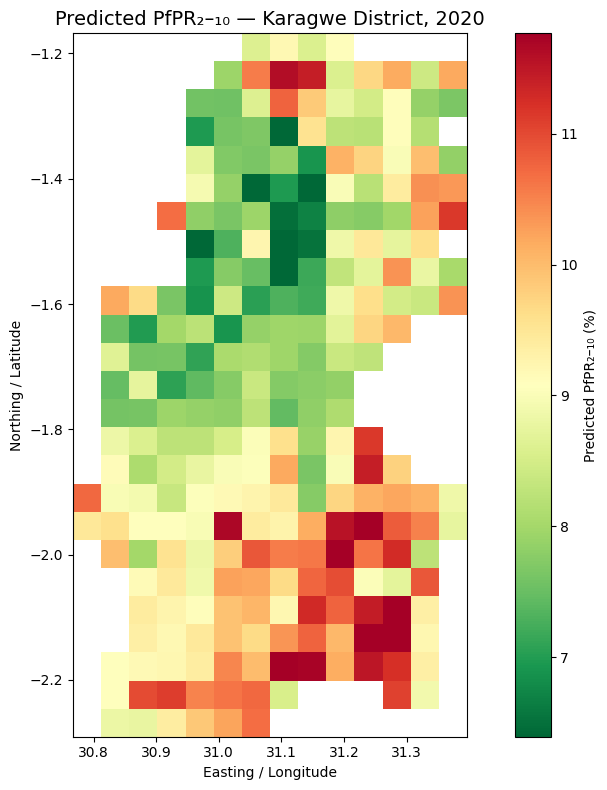

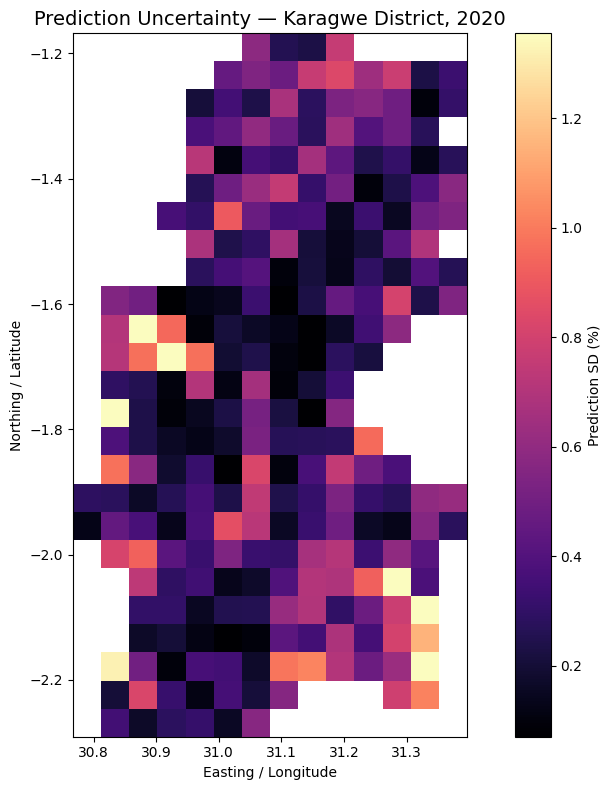


Saved files:
Prediction PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2020.png
Uncertainty PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_2020.png
Prediction GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2020.tif
Uncertainty GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_SD_2020.tif

PROCESSING YEAR 2021
Total pixels: 350
Valid pixels: 255
Outer XGBoost model 1 completed.
Outer XGBoost model 2 completed.
Outer XGBoost model 3 completed.
Outer XGBoost model 4 completed.
Outer XGBoost model 5 completed.


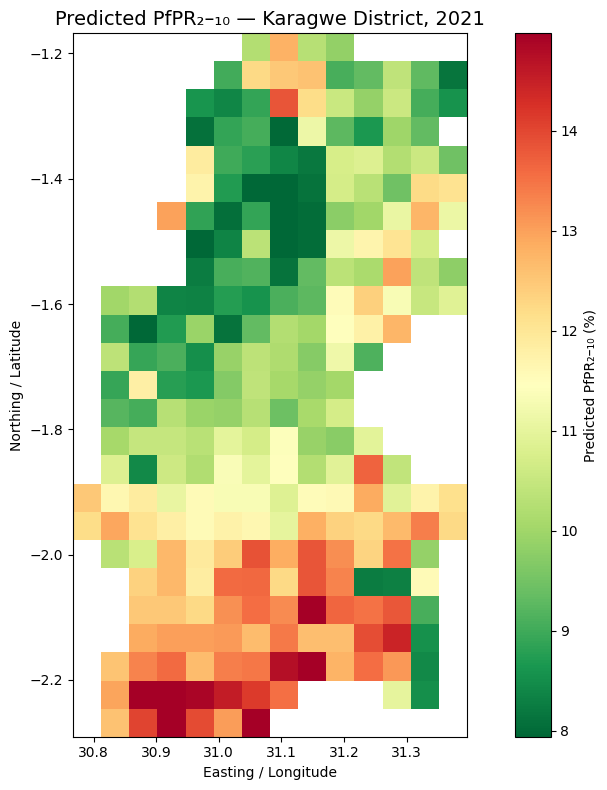

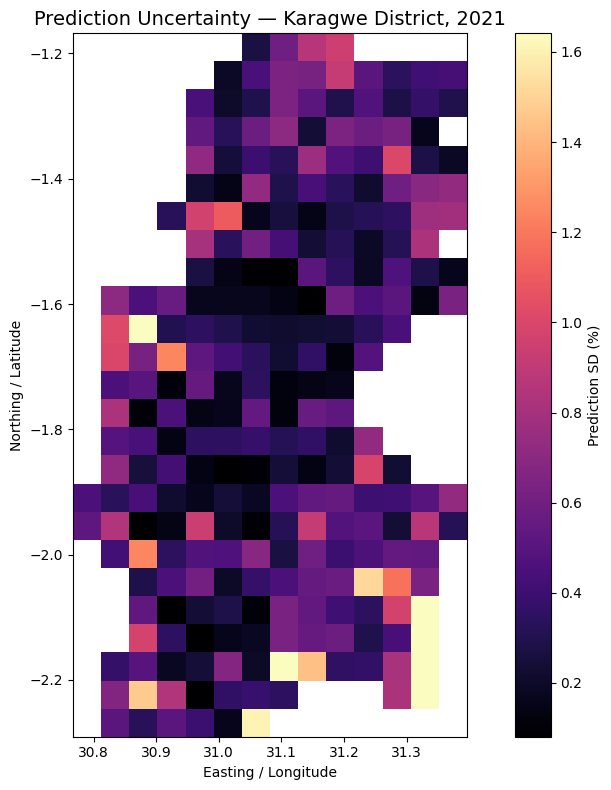


Saved files:
Prediction PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2021.png
Uncertainty PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_2021.png
Prediction GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2021.tif
Uncertainty GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_SD_2021.tif

PROCESSING YEAR 2022
Total pixels: 350
Valid pixels: 255
Outer XGBoost model 1 completed.
Outer XGBoost model 2 completed.
Outer XGBoost model 3 completed.
Outer XGBoost model 4 completed.
Outer XGBoost model 5 completed.


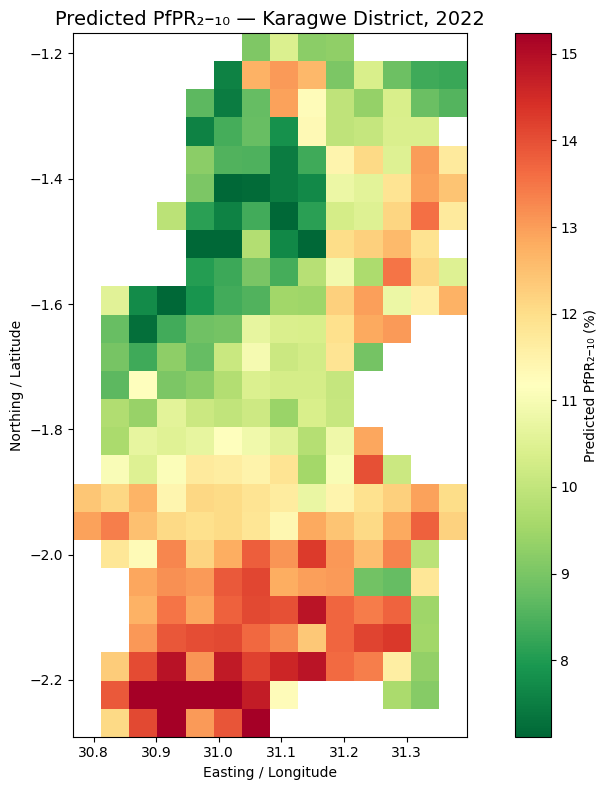

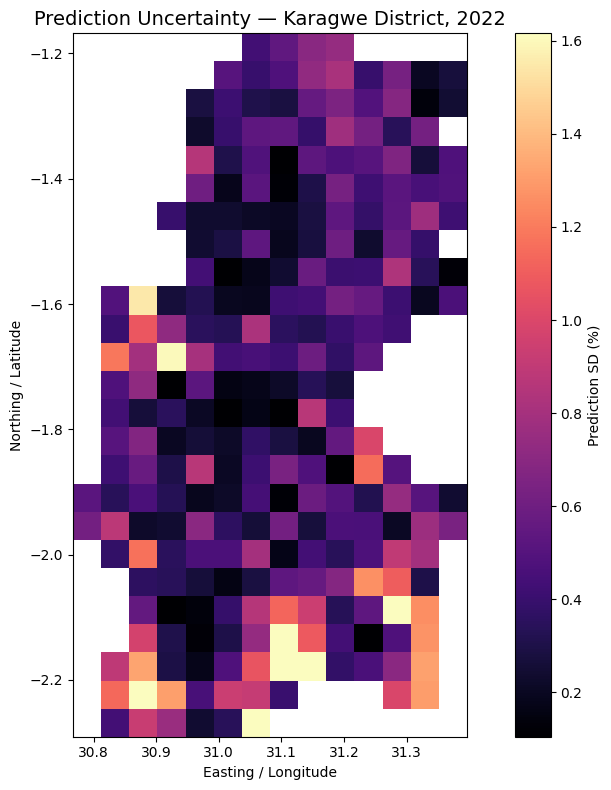


Saved files:
Prediction PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2022.png
Uncertainty PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_2022.png
Prediction GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2022.tif
Uncertainty GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_SD_2022.tif

PROCESSING YEAR 2023
Total pixels: 350
Valid pixels: 255
Outer XGBoost model 1 completed.
Outer XGBoost model 2 completed.
Outer XGBoost model 3 completed.
Outer XGBoost model 4 completed.
Outer XGBoost model 5 completed.


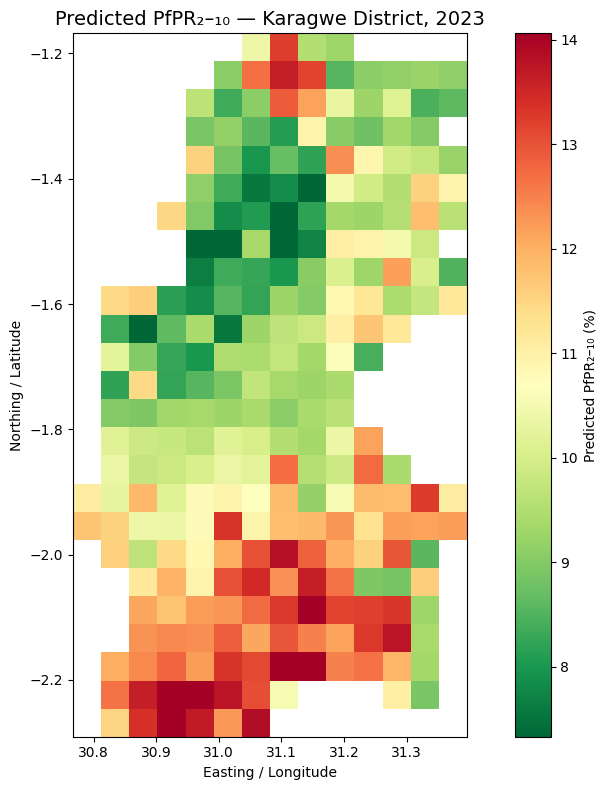

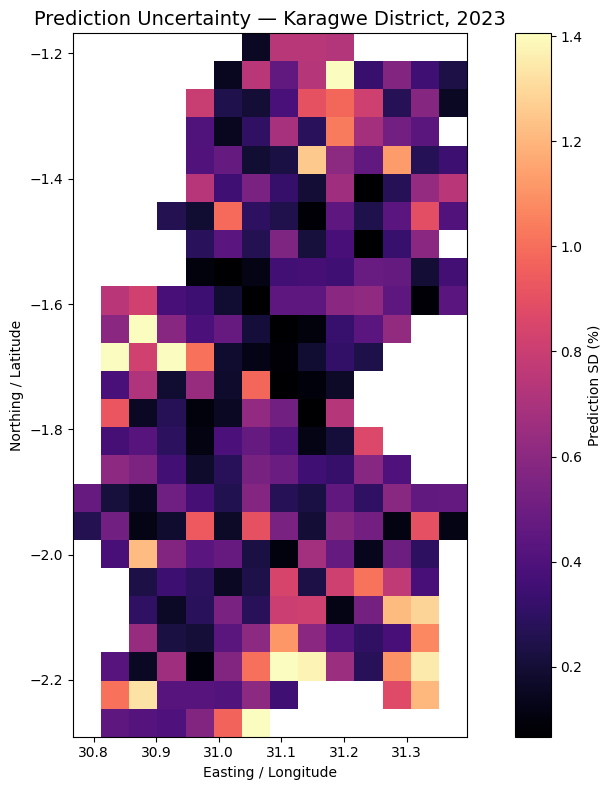


Saved files:
Prediction PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2023.png
Uncertainty PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_2023.png
Prediction GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2023.tif
Uncertainty GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_SD_2023.tif

PROCESSING YEAR 2024
Total pixels: 350
Valid pixels: 255
Outer XGBoost model 1 completed.
Outer XGBoost model 2 completed.
Outer XGBoost model 3 completed.
Outer XGBoost model 4 completed.
Outer XGBoost model 5 completed.


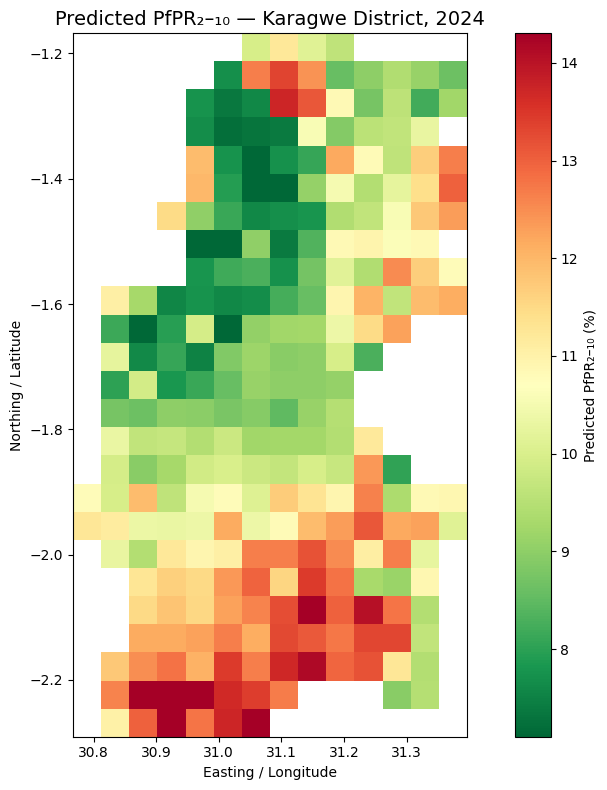

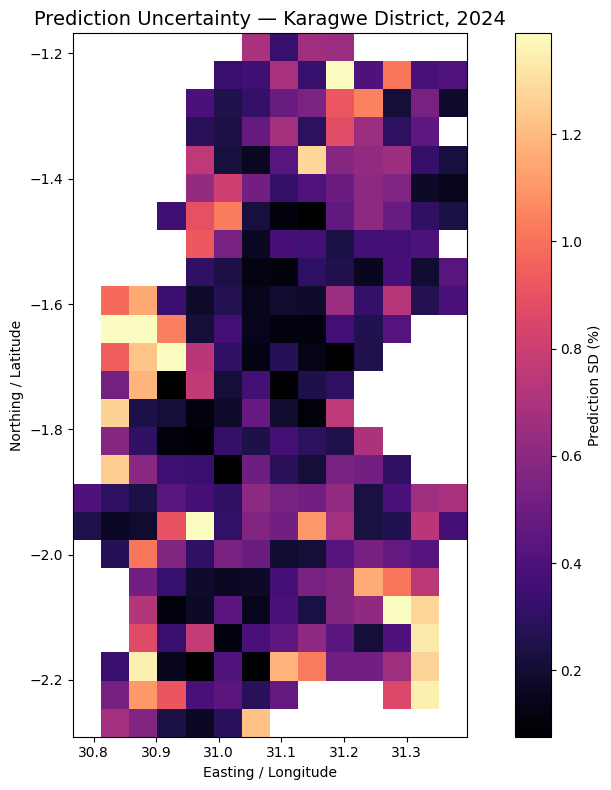


Saved files:
Prediction PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2024.png
Uncertainty PNG: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_2024.png
Prediction GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/Predicted_PfPR2_10_2024.tif
Uncertainty GeoTIFF: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps/PfPR2_10_Uncertainty_SD_2024.tif

ALL MAPS COMPLETED

Output folder: /content/drive/MyDrive/PfPR_Project/Predicted_PfPR_Maps


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pandas as pd # Import pandas

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

YEARS = [2020, 2021, 2022, 2023, 2024]

STACK_DIR = "/content/drive/MyDrive/PfPR_Predictors/"

MAP_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "Predicted_PfPR_Maps"
)

os.makedirs(MAP_OUTPUT_DIR, exist_ok=True)

# Your 10-band raster order
STACK_BAND_ORDER = [
    "NDVI",
    "NDWI",
    "NDMI",
    "NDBI",
    "MNDWI",
    "LST",
    "Rainfall",
    "Elevation",
    "Slope",
    "DistWater"
]

# Final six predictors used by XGBoost
MODEL_FEATURES = [
    "NDWI",
    "NDMI",
    "LST",
    "Rainfall",
    "Elevation",
    "DistWater"
]

# Find their positions in the 10-band raster
feature_indices = [
    STACK_BAND_ORDER.index(feature)
    for feature in MODEL_FEATURES
]

print("Final model features:")
print(MODEL_FEATURES)

print("\nRaster band indices:")
print(feature_indices)

# ------------------------------------------------------------
# 2. CHECK THAT FINAL MODEL EXISTS
# ------------------------------------------------------------

if "final_model" not in globals():
    raise NameError(
        "final_model was not found. "
        "Run the final deployment-model section of your notebook first."
    )

# ------------------------------------------------------------
# 3. CHECK THAT OUTER XGBOOST MODELS EXIST
# ------------------------------------------------------------

if "spatial_fold_models" not in globals():
    raise NameError(
        "spatial_fold_models was not found. "
        "Run the nested spatial CV section first."
    )

if "XGBoost" not in spatial_fold_models:
    raise KeyError(
        "XGBoost outer-fold models were not found."
    )

xgb_outer_models = spatial_fold_models["XGBoost"]

print(
    "\nNumber of outer XGBoost models:",
    len(xgb_outer_models)
)

# ------------------------------------------------------------
# 4. PROCESS EACH YEAR
# ------------------------------------------------------------

for year in YEARS:

    print("\n" + "=" * 70)
    print(f"PROCESSING YEAR {year}")
    print("=" * 70)

    raster_path = os.path.join(
        STACK_DIR,
        f"Karagwe_Predictor_Stack{year}.tif"
    )

    if not os.path.exists(raster_path):

        print(
            f"WARNING: Raster not found:\n{raster_path}"

        )

        continue

    with rasterio.open(raster_path) as src:

        # ----------------------------------------------------
        # Read the six predictors
        # ----------------------------------------------------

        predictor_stack = src.read(
            [i + 1 for i in feature_indices]
        ).astype("float32")

        height = src.height
        width = src.width

        transform = src.transform
        extent = [
            transform.c,
            transform.c + transform.a * width,
            transform.f + transform.e * height,
            transform.f
        ]

        profile = src.profile.copy()

        # ----------------------------------------------------
        # Convert raster to rows = pixels
        # ----------------------------------------------------

        X_raster = predictor_stack.reshape(
            len(MODEL_FEATURES),
            -1
        ).T

        # ----------------------------------------------------
        # Identify valid pixels
        # ----------------------------------------------------

        valid_pixels = np.all(
            np.isfinite(X_raster),
            axis=1
        )

        print(
            "Total pixels:",
            len(X_raster)
        )

        print(
            "Valid pixels:",
            valid_pixels.sum()
        )

        # ====================================================
        # A. FINAL XGBOOST PREDICTION
        # ====================================================

        prediction = np.full(
            len(X_raster),
            np.nan,
            dtype="float32"
        )

        if valid_pixels.any():
            X_raster_df = pd.DataFrame(
                X_raster[valid_pixels],
                columns=MODEL_FEATURES
            )
            prediction[valid_pixels] = final_model.predict(X_raster_df)

        prediction_raster = prediction.reshape(
            height,
            width
        )

        # ====================================================
        # B. OUTER-FOLD PREDICTIONS
        #    Used for model-spread uncertainty
        # ====================================================

        fold_predictions = []

        for fold_number, model_dict in enumerate( # Renamed 'model' to 'model_dict'
            xgb_outer_models,
            start=1
        ):

            fold_prediction = np.full(
                len(X_raster),
                np.nan,
                dtype="float32"
            )

            if valid_pixels.any():
                # Access the actual model from the dictionary
                model_pipeline = model_dict['best_estimator']

                # Convert to DataFrame with named columns
                X_raster_df_outer = pd.DataFrame(
                    X_raster[valid_pixels],
                    columns=MODEL_FEATURES
                )

                fold_prediction[valid_pixels] = model_pipeline.predict(X_raster_df_outer)

            fold_predictions.append(
                fold_prediction
            )

            print(
                f"Outer XGBoost model {fold_number} completed."
            )

        fold_predictions = np.vstack(
            fold_predictions
        )

        # ====================================================
        # C. UNCERTAINTY
        #    Standard deviation across outer-fold models
        # ====================================================

        uncertainty = np.full(
            len(X_raster),
            np.nan,
            dtype="float32"
        )

        uncertainty[valid_pixels] = np.nanstd(
            fold_predictions[:, valid_pixels],
            axis=0,
            ddof=1
        )

        uncertainty_raster = uncertainty.reshape(
            height,
            width
        )

        # ====================================================
        # D. SAVE PREDICTION GEOTIFF
        # ====================================================

        prediction_tif = os.path.join(
            MAP_OUTPUT_DIR,
            f"Predicted_PfPR2_10_{year}.tif"
        )

        profile.update(
            dtype="float32",
            count=1,
            compress="deflate",
            nodata=-9999
        )

        prediction_to_save = np.where(
            np.isfinite(prediction_raster),
            prediction_raster,
            -9999
        ).astype("float32")

        with rasterio.open(
            prediction_tif,
            "w",
            **profile
        ) as dst:

            dst.write(
                prediction_to_save,
                1
            )

        # ====================================================
        # E. SAVE UNCERTAINTY GEOTIFF
        # ====================================================

        uncertainty_tif = os.path.join(
            MAP_OUTPUT_DIR,
            f"PfPR2_10_Uncertainty_SD_{year}.tif"
        )

        uncertainty_to_save = np.where(
            np.isfinite(uncertainty_raster),
            uncertainty_raster,
            -9999
        ).astype("float32")

        with rasterio.open(
            uncertainty_tif,
            "w",
            **profile
        ) as dst:

            dst.write(
                uncertainty_to_save,
                1
            )

        # ====================================================
        # F. PLOT PREDICTED PfPR MAP
        # ====================================================

        plt.figure(figsize=(10, 8))

        valid_prediction_values = (
            prediction_raster[
                np.isfinite(prediction_raster)
            ]
        )

        vmin_pred = np.percentile(
            valid_prediction_values,
            2
        )

        vmax_pred = np.percentile(
            valid_prediction_values,
            98
        )

        im = plt.imshow(
            prediction_raster,
            extent=extent,
            cmap="RdYlGn_r",
            vmin=vmin_pred,
            vmax=vmax_pred
        )

        plt.colorbar(
            im,
            label="Predicted PfPR₂–₁₀ (%)"
        )

        plt.title(
            f"Predicted PfPR₂–₁₀ — Karagwe District, {year}",
            fontsize=14
        )

        plt.xlabel("Easting / Longitude")
        plt.ylabel("Northing / Latitude")

        plt.tight_layout()

        prediction_png = os.path.join(
            MAP_OUTPUT_DIR,
            f"Predicted_PfPR2_10_{year}.png"
        )

        plt.savefig(
            prediction_png,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        # ====================================================
        # G. PLOT UNCERTAINTY MAP
        # ====================================================

        plt.figure(figsize=(10, 8))

        valid_uncertainty_values = (
            uncertainty_raster[
                np.isfinite(uncertainty_raster)
            ]
        )

        vmin_unc = np.percentile(
            valid_uncertainty_values,
            2
        )

        vmax_unc = np.percentile(
            valid_uncertainty_values,
            98
        )

        im2 = plt.imshow(
            uncertainty_raster,
            extent=extent,
            cmap="magma",
            vmin=vmin_unc,
            vmax=vmax_unc
        )

        plt.colorbar(
            im2,
            label="Prediction SD (%)"
        )

        plt.title(
            f"Prediction Uncertainty — Karagwe District, {year}",
            fontsize=14
        )

        plt.xlabel("Easting / Longitude")
        plt.ylabel("Northing / Latitude")

        plt.tight_layout()

        uncertainty_png = os.path.join(
            MAP_OUTPUT_DIR,
            f"PfPR2_10_Uncertainty_{year}.png"
        )

        plt.savefig(
            uncertainty_png,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        # ====================================================
        # H. PRINT FILES
        # ====================================================

        print("\nSaved files:")

        print(
            "Prediction PNG:",
            prediction_png
        )

        print(
            "Uncertainty PNG:",
            uncertainty_png
        )

        print(
            "Prediction GeoTIFF:",
            prediction_tif
        )

        print(
            "Uncertainty GeoTIFF:",
            uncertainty_tif
        )


print("\n" + "=" * 70)
print("ALL MAPS COMPLETED")
print("=" * 70)

print(
    "\nOutput folder:",
    MAP_OUTPUT_DIR
)


NUMBER OF SPATIAL BLOCKS
 5 km blocks: 132 occupied blocks
10 km blocks: 54 occupied blocks
20 km blocks: 18 occupied blocks


   Block_Size_km  Number_of_Blocks
0              5               132
1             10                54
2             20                18


RUNNING NESTED SPATIAL CV WITH 5-KM BLOCKS

Block size: 5 km
Occupied spatial blocks: 132

Running Random Forest (5 km)...
Random Forest | Spatial fold 1: R2=0.7284, RMSE=1.0855, MAE=0.7560
Random Forest | Spatial fold 2: R2=0.5572, RMSE=1.3772, MAE=0.8313
Random Forest | Spatial fold 3: R2=0.5229, RMSE=1.5949, MAE=0.8572
Random Forest | Spatial fold 4: R2=0.6869, RMSE=1.0937, MAE=0.7707
Random Forest | Spatial fold 5: R2=0.7440, RMSE=1.2637, MAE=0.8741

Running XGBoost (5 km)...
XGBoost | Spatial fold 1: R2=0.6784, RMSE=1.1812, MAE=0.8098
XGBoost | Spatial fold 2: R2=0.6344, RMSE=1.2514, MAE=0.8098
XGBoost | Spatial fold 3: R2=0.5401, RMSE=1.5658, MAE=0.8287
XGBoost | Spatial fold 4: R2=0.6355, RMSE=1.1801, MAE=0.8497
X

,Block_Size_km,Number_of_Blocks,Model,Mean_R2,SD_R2,Mean_RMSE,SD_RMSE,Mean_MAE,SD_MAE
0,5,132,Random Forest,0.6479,0.1014,1.2830,0.2129,0.8179,0.0523
1,5,132,XGBoost,0.6509,0.0819,1.2772,0.1639,0.8272,0.0176
2,10,54,Random Forest,0.5128,0.1675,1.4758,0.2130,1.0228,0.1974
3,10,54,XGBoost,0.5505,0.1856,1.4093,0.2325,0.9936,0.1953
4,20,18,Random Forest,0.2392,0.2587,1.6605,0.3485,1.2837,0.2619
5,20,18,XGBoost,0.2055,0.3746,1.6684,0.3958,1.2687,0.2755



Saved:
/content/drive/MyDrive/PfPR_Project/Block_Size_Sensitivity/spatial_block_size_sensitivity_summary.csv
/content/drive/MyDrive/PfPR_Project/Block_Size_Sensitivity/spatial_block_size_sensitivity_hyperparameters.csv


COMPARISON TABLE


,Block_Size_km,Number_of_Blocks,Model,Mean_R2,Mean_RMSE,Mean_MAE
0,5,132,Random Forest,0.6479,1.2830,0.8179
1,5,132,XGBoost,0.6509,1.2772,0.8272
2,10,54,Random Forest,0.5128,1.4758,1.0228
3,10,54,XGBoost,0.5505,1.4093,0.9936
4,20,18,Random Forest,0.2392,1.6605,1.2837
5,20,18,XGBoost,0.2055,1.6684,1.2687


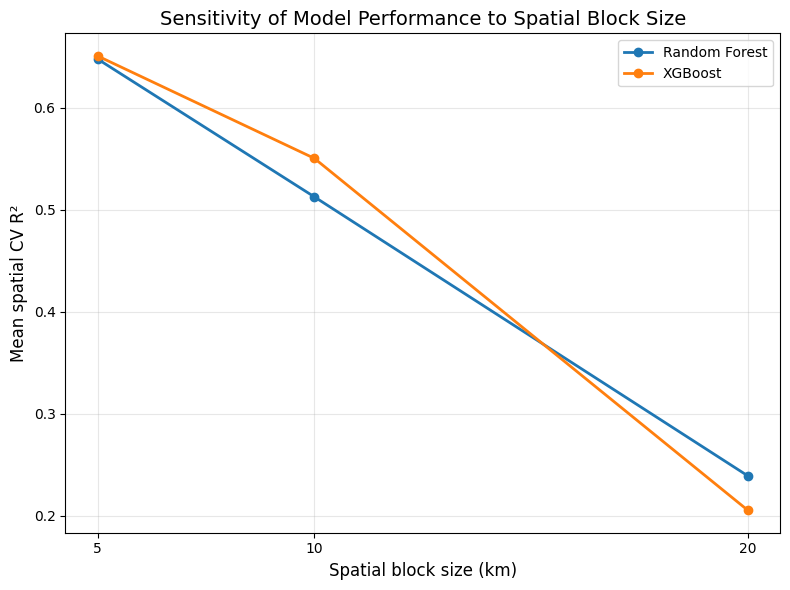


Sensitivity plot saved to: /content/drive/MyDrive/PfPR_Project/Block_Size_Sensitivity/block_size_sensitivity_R2.png


In [25]:
# ============================================================
# SPATIAL BLOCK-SIZE SENSITIVITY ANALYSIS
# 5 km, 10 km and 20 km
# ============================================================

import os
import numpy as np
import pandas as pd
from pyproj import Transformer

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

BLOCK_SIZES_KM = [5, 10, 20]

# Keep the same number of outer folds as the main analysis
N_SENSITIVITY_FOLDS = 5

SENSITIVITY_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "Block_Size_Sensitivity"
)

os.makedirs(
    SENSITIVITY_OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# RE-DEFINE MODEL HYPERPARAMETER DICTIONARIES GLOBALLY
# This is to prevent accidental overwrites from previous operations
# ============================================================

rf_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

xgb_params = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1, 2, 5]
}


# ============================================================
# 1. FUNCTION TO CREATE SPATIAL BLOCKS
# ============================================================

def create_spatial_blocks(
    input_data,
    block_size_km
):
    """
    Create regular square spatial blocks in a metric UTM CRS.

    Parameters
    ----------
    input_data : pandas.DataFrame
        Must contain longitude and latitude.
    block_size_km : float
        Spatial block size in kilometres.

    Returns
    -------
    data_blocked : pandas.DataFrame
        Copy of input data with spatial_block column.
    """

    data_blocked = input_data.copy()

    # --------------------------------------------------------
    # Determine UTM zone from study-area coordinates
    # --------------------------------------------------------

    mean_lon = data_blocked["longitude"].mean()
    mean_lat = data_blocked["latitude"].mean()

    utm_zone = int(
        (mean_lon + 180) // 6
    ) + 1

    if mean_lat >= 0:
        epsg = 32600 + utm_zone
    else:
        epsg = 32700 + utm_zone

    transformer = Transformer.from_crs(
        "EPSG:4326",
        f"EPSG:{epsg}",
        always_xy=True
    )

    # --------------------------------------------------------
    # Convert longitude/latitude to metres
    # --------------------------------------------------------

    x_m, y_m = transformer.transform(
        data_blocked["longitude"].to_numpy(),
        data_blocked["latitude"].to_numpy()
    )

    data_blocked["x_m"] = x_m
    data_blocked["y_m"] = y_m

    # --------------------------------------------------------
    # Create square blocks
    # --------------------------------------------------------

    block_m = block_size_km * 1000

    data_blocked["block_x"] = np.floor(
        data_blocked["x_m"] / block_m
    ).astype(int)

    data_blocked["block_y"] = np.floor(
        data_blocked["y_m"] / block_m
    ).astype(int)

    data_blocked["spatial_block"] = (
        data_blocked["block_x"].astype(str)
        + "_"
        + data_blocked["block_y"].astype(str)
    )

    return data_blocked


# ============================================================
# 2. FIRST CHECK HOW MANY BLOCKS EACH SIZE PRODUCES
# ============================================================

print("\n" + "=" * 80)
print("NUMBER OF SPATIAL BLOCKS")
print("=" * 80)

block_counts = []

for block_size in BLOCK_SIZES_KM:

    temp = create_spatial_blocks(
        data,
        block_size
    )

    n_blocks = (
        temp["spatial_block"]
        .nunique()
    )

    block_counts.append({
        "Block_Size_km": block_size,
        "Number_of_Blocks": n_blocks
    })

    print(
        f"{block_size:>2} km blocks: "
        f"{n_blocks} occupied blocks"
    )

block_counts_df = pd.DataFrame(
    block_counts
)

print("\n")
print(block_counts_df)


# ============================================================
# 3. RUN NESTED SPATIAL CV FOR EACH BLOCK SIZE
# ============================================================

all_sensitivity_results = []
all_sensitivity_params = []

for block_size in BLOCK_SIZES_KM:

    print("\n")
    print("=" * 80)
    print(
        f"RUNNING NESTED SPATIAL CV "
        f"WITH {block_size}-KM BLOCKS"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Create spatial blocks
    # --------------------------------------------------------

    sensitivity_data = create_spatial_blocks(
        data,
        block_size
    )

    n_blocks = (
        sensitivity_data["spatial_block"]
        .nunique()
    )

    print(
        f"\nBlock size: {block_size} km"
    )

    print(
        f"Occupied spatial blocks: {n_blocks}"
    )

    # --------------------------------------------------------
    # Make sure enough groups exist for 5-fold CV
    # --------------------------------------------------------

    if n_blocks < N_SENSITIVITY_FOLDS:

        print(
            f"\nSKIPPING {block_size} km: "
            f"only {n_blocks} blocks are available "
            f"for {N_SENSITIVITY_FOLDS}-fold CV."
        )

        continue

    # --------------------------------------------------------
    # X and y remain EXACTLY the same
    # --------------------------------------------------------

    X_sensitivity = (
        sensitivity_data[
            MODEL_FEATURES
        ].copy()
    )

    y_sensitivity = (
        sensitivity_data[
            TARGET
        ].copy()
    )

    # --------------------------------------------------------
    # Run Random Forest
    # --------------------------------------------------------

    print(
        f"\nRunning Random Forest "
        f"({block_size} km)..."
    )

    (
        rf_sensitivity_results,
        rf_sensitivity_params,
        _,
        _,
        _ # Unpack all 5 return values
    ) = nested_spatial_cv(
        sensitivity_data,
        X_sensitivity,
        y_sensitivity,
        "Random Forest"
    )

    # --------------------------------------------------------
    # Run XGBoost
    # --------------------------------------------------------

    print(
        f"\nRunning XGBoost "
        f"({block_size} km)..."
    )

    (
        xgb_sensitivity_results,
        xgb_sensitivity_params,
        _,
        _,
        _ # Unpack all 5 return values
    ) = nested_spatial_cv(
        sensitivity_data,
        X_sensitivity,
        y_sensitivity,
        "XGBoost"
    )

    # --------------------------------------------------------
    # Combine model results
    # --------------------------------------------------------

    block_results = pd.concat(
        [
            rf_sensitivity_results,
            xgb_sensitivity_results
        ],
        ignore_index=True
    )

    block_params = pd.concat(
        [
            rf_sensitivity_params,
            xgb_sensitivity_params
        ],
        ignore_index=True
    )

    # --------------------------------------------------------
    # Calculate summary statistics
    # --------------------------------------------------------

    summary = (
        block_results
        .groupby("Model")
        .agg(
            Mean_R2=("R2", "mean"),
            SD_R2=("R2", "std"),
            Mean_RMSE=("RMSE", "mean"),
            SD_RMSE=("RMSE", "std"),
            Mean_MAE=("MAE", "mean"),
            SD_MAE=("MAE", "std")
        )
        .reset_index()
    )

    summary["Block_Size_km"] = block_size
    summary["Number_of_Blocks"] = n_blocks

    # Reorder columns
    summary = summary[
        [
            "Block_Size_km",
            "Number_of_Blocks",
            "Model",
            "Mean_R2",
            "SD_R2",
            "Mean_RMSE",
            "SD_RMSE",
            "Mean_MAE",
            "SD_MAE"
        ]
    ]

    all_sensitivity_results.append(
        summary
    )

    # --------------------------------------------------------
    # Add block size to hyperparameter table
    # --------------------------------------------------------

    block_params["Block_Size_km"] = block_size
    block_params["Number_of_Blocks"] = n_blocks

    all_sensitivity_params.append(
        block_params
    )

    # --------------------------------------------------------
    # Save individual block-size results
    # --------------------------------------------------------

    summary.to_csv(
        os.path.join(
            SENSITIVITY_OUTPUT_DIR,
            f"sensitivity_{block_size}km_summary.csv"
        ),
        index=False
    )

    block_params.to_csv(
        os.path.join(
            SENSITIVITY_OUTPUT_DIR,
            f"sensitivity_{block_size}km_hyperparameters.csv"
        ),
        index=False
    )


# ============================================================
# 4. COMBINE ALL RESULTS
# ============================================================

if len(all_sensitivity_results) == 0:

    raise RuntimeError(
        "No block-size sensitivity analysis was completed."
    )

sensitivity_summary = pd.concat(
    all_sensitivity_results,
    ignore_index=True
)

sensitivity_parameters = pd.concat(
    all_sensitivity_params,
    ignore_index=True
)


# ============================================================
# 5. SORT RESULTS
# ============================================================

sensitivity_summary = (
    sensitivity_summary
    .sort_values(
        ["Block_Size_km", "Model"]
    )
    .reset_index(drop=True)
)

sensitivity_parameters = (
    sensitivity_parameters
    .sort_values(
        ["Block_Size_km", "Model", "Fold"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 6. DISPLAY FINAL SENSITIVITY TABLE
# ============================================================

print("\n")
print("=" * 80)
print("SPATIAL BLOCK-SIZE SENSITIVITY RESULTS")
print("=" * 80)

display(
    sensitivity_summary.round(4)
)


# ============================================================
# 7. SAVE FINAL TABLE
# ============================================================

summary_file = os.path.join(
    SENSITIVITY_OUTPUT_DIR,
    "spatial_block_size_sensitivity_summary.csv"
)

parameters_file = os.path.join(
    SENSITIVITY_OUTPUT_DIR,
    "spatial_block_size_sensitivity_hyperparameters.csv"
)

sensitivity_summary.to_csv(
    summary_file,
    index=False
)

sensitivity_parameters.to_csv(
    parameters_file,
    index=False
)

print("\nSaved:")
print(summary_file)
print(parameters_file)


# ============================================================
# 8. SIMPLE COMPARISON TABLE
# ============================================================

comparison_table = sensitivity_summary[
    [
        "Block_Size_km",
        "Number_of_Blocks",
        "Model",
        "Mean_R2",
        "Mean_RMSE",
        "Mean_MAE"
    ]
].copy()

print("\n")
print("=" * 80)
print("COMPARISON TABLE")
print("=" * 80)

display(
    comparison_table.round(4)
)


# ============================================================
# 9. PLOT R² AGAINST BLOCK SIZE
# ============================================================

plt.figure(figsize=(8, 6))

for model in ["Random Forest", "XGBoost"]:

    subset = sensitivity_summary[
        sensitivity_summary["Model"] == model
    ]

    plt.plot(
        subset["Block_Size_km"],
        subset["Mean_R2"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.xlabel(
    "Spatial block size (km)",
    fontsize=12
)

plt.ylabel(
    "Mean spatial CV R²",
    fontsize=12
)

plt.title(
    "Sensitivity of Model Performance to Spatial Block Size",
    fontsize=14
)

plt.xticks(
    BLOCK_SIZES_KM
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

sensitivity_plot = os.path.join(
    SENSITIVITY_OUTPUT_DIR,
    "block_size_sensitivity_R2.png"
)

plt.savefig(
    sensitivity_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSensitivity plot saved to:",
    sensitivity_plot
)


In [28]:
fold_results[
    ["Model", "Fold", "Train_n", "Validation_n", "Validation_blocks"]
]

,Model,Fold,Train_n,Validation_n,Validation_blocks
0,Random Forest,1,1170,295,10.0
1,Random Forest,2,1170,295,10.0
2,Random Forest,3,1170,295,12.0
3,Random Forest,4,1175,290,11.0
4,Random Forest,5,1175,290,11.0
5,Random Forest,1,1172,293,NaN
6,Random Forest,2,1172,293,NaN
7,Random Forest,3,1172,293,NaN
8,Random Forest,4,1172,293,NaN
9,Random Forest,5,1172,293,NaN


In [30]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

fold_r2 = []
fold_rmse = []
fold_mae = []

# Filter predictions for the selected model and primary scheme
# Assuming 'cv_predictions', 'selected_model_name', 'PRIMARY_SCHEME', and 'TARGET' are available from previous cells.
filtered_predictions = cv_predictions[
    (cv_predictions['Model'] == selected_model_name) &
    (cv_predictions['Scheme'] == PRIMARY_SCHEME)
]

# Get unique fold numbers to iterate through
unique_folds = sorted(filtered_predictions['Fold'].unique())

if not unique_folds:
    print(f"No predictions found for {selected_model_name} under {PRIMARY_SCHEME}.")
else:
    for fold_num in unique_folds:
        fold_data = filtered_predictions[filtered_predictions['Fold'] == fold_num]

        y_true_fold = fold_data[TARGET]
        y_pred_fold = fold_data['prediction']

        if not y_true_fold.empty: # Ensure there's data for the fold
            fold_r2.append(
                r2_score(y_true_fold, y_pred_fold)
            )

            fold_rmse.append(
                np.sqrt(
                    mean_squared_error(
                        y_true_fold,
                        y_pred_fold
                    )
                )
            )

            fold_mae.append(
                mean_absolute_error(
                    y_true_fold,
                    y_pred_fold
                )
            )
        else:
            print(f"Warning: No data for Fold {fold_num} for {selected_model_name} in {PRIMARY_SCHEME}.")

    if fold_r2: # Only calculate means if there are results
        mean_r2 = np.mean(fold_r2)
        mean_rmse = np.mean(fold_rmse)
        mean_mae = np.mean(fold_mae)

        print("Mean R²:", mean_r2)
        print("Mean RMSE:", mean_rmse)
        print("Mean MAE:", mean_mae)

        # The 'ax' object is not defined in this standalone cell and requires a matplotlib figure/axes object.
        # If you intend to add text to a plot, please ensure the plot is created and 'ax' is defined.
        # ax.text(
        #     0.05,
        #     0.95,
        #     f"R² = {mean_r2:.3f}\n"
        #     f"RMSE = {mean_rmse:.3f}\n"
        #     f"MAE = {mean_mae:.3f}",
        #     transform=ax.transAxes,
        #     verticalalignment="top"
        # )
    else:
        print("Could not calculate mean metrics as no fold data was processed.")

Mean R²: 0.5505321145313883
Mean RMSE: 1.4092957902722159
Mean MAE: 0.9936364499962176
